In [ ]:
# ============================================================
# CELL 1: Install & Imports
# ============================================================
!pip install -q ultralytics
!pip install transformers timm umap-learn paddleocr -q

import os, json, cv2
import numpy as np
import pandas as pd 
from pathlib import Path
from tqdm import tqdm
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

from transformers import ViTModel
from torchvision import transforms
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# ── CJK font fix: suppress "Glyph missing" warnings for Chinese labels ──
# Try to find a CJK-capable font (available in Kaggle / Colab environments)
_cjk_fonts = ['Noto Sans CJK SC', 'WenQuanYi Micro Hei', 'SimHei', 'AR PL UMing CN']
_found_cjk = None
for _fn in _cjk_fonts:
    if any(_fn.lower() in f.name.lower() for f in fm.fontManager.ttflist):
        _found_cjk = _fn
        break
if _found_cjk:
    plt.rcParams['font.family'] = ['DejaVu Sans', _found_cjk]
else:
    # Install Noto CJK if missing (Kaggle/Colab have internet)
    try:
        import subprocess
        subprocess.run(['apt-get', 'install', '-y', '-q', 'fonts-noto-cjk'],
                      capture_output=True, check=False)
        fm._load_fontmanager(try_read_cache=False)  # rebuild cache
    except Exception:
        pass  # Non-fatal; Chinese labels will show squares but code runs

try:
    import umap
    HAS_UMAP = True
except ImportError:
    from sklearn.manifold import TSNE
    HAS_UMAP = False

from sklearn.metrics.pairwise import cosine_similarity

DEVICE    = 'cuda' if torch.cuda.is_available() else 'cpu'
DATA_ROOT = '/kaggle/input/datasets/diyer22/retail-product-checkout-dataset'
WORK_ROOT = '/kaggle/working'
CROP_DIR  = f'{WORK_ROOT}/crops'

# ── Hyperparameters ─────────────────────────────────────────
IMG_SIZE          = 224
EMBED_DIM         = 128
TEMPERATURE       = 0.07
YOLO_CONF_MIN     = 0.30
CROP_MIN_PX       = 24
ASPECT_MIN        = 0.15
ASPECT_MAX        = 6.00
OCR_FALLBACK_SIM  = 0.40   # ViT sim below this → also try OCR
TTA_ENABLED       = True
USE_PATCH_TOKENS  = True

# Balanced sampler: 8 classes × 8 samples = 64 per batch
SAMPLES_PER_CLASS = 8
CLASSES_PER_BATCH = 8
BATCH_SIZE        = SAMPLES_PER_CLASS * CLASSES_PER_BATCH

print(f'Device: {DEVICE}')
print(f'Batch size: {BATCH_SIZE}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 23.1 MB/s eta 0:00:00


2026-04-12 12:11:13.804503: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775995873.997283      21 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775995874.062193      21 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775995874.506498      21 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775995874.506548      21 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775995874.506551      21 computation_placer.cc:177] computation placer alr

Device: cuda
Batch size: 64


In [2]:
# ============================================================
# CELL 2: Load metadata + build sku_lookup
# FIXED: Added all 25 missing brands from dataset audit
# ============================================================
with open(f'{DATA_ROOT}/instances_train2019.json', 'rb') as f:
    train_data = json.load(f)

# Also load val2019 and test2019 annotation files
# NOTE: val2019 & test2019 have checkout scene images (12 objects/image)
# We use their BOUNDING BOX annotations to crop individual products
# for HONEST evaluation — this is the real-world difficulty split
with open(f'{DATA_ROOT}/instances_val2019.json', 'rb') as f:
    val2019_data = json.load(f)
with open(f'{DATA_ROOT}/instances_test2019.json', 'rb') as f:
    test2019_data = json.load(f)

sku_df   = pd.DataFrame(train_data['__raw_Chinese_name_df'])
anns_df  = pd.DataFrame(train_data['annotations'])
imgs_df  = pd.DataFrame(train_data['images'])
img_dict = imgs_df.set_index('id')['file_name'].to_dict()

# val2019 / test2019 annotation DataFrames (for checkout-scene eval)
val2019_anns  = pd.DataFrame(val2019_data['annotations'])
val2019_imgs  = pd.DataFrame(val2019_data['images'])
val2019_dict  = val2019_imgs.set_index('id')['file_name'].to_dict()

test2019_anns = pd.DataFrame(test2019_data['annotations'])
test2019_imgs = pd.DataFrame(test2019_data['images'])
test2019_dict = test2019_imgs.set_index('id')['file_name'].to_dict()

print(f'val2019:  {len(val2019_imgs)} checkout images, {len(val2019_anns)} annotations')
print(f'test2019: {len(test2019_imgs)} checkout images, {len(test2019_anns)} annotations')

cat_ids      = sorted(sku_df['category_id'].unique().tolist())
cat_to_label = {c: i for i, c in enumerate(cat_ids)}
label_to_cat = {i: c for c, i in cat_to_label.items()}
NUM_CLASSES  = len(cat_ids)
print(f'Unique SKUs: {NUM_CLASSES}')

# ── Complete BRAND_MAP (all 200 RPC SKUs, zero gaps) ─────────
BRAND_MAP = {
    # Beverages
    '百事可乐': 'Pepsi', '可口可乐': 'Coca-Cola', '雪碧': 'Sprite',
    '芬达': 'Fanta', '农夫山泉': 'Nongfu Spring', '王老吉': 'Wanglaoji',
    '加多宝': 'Jiaduobao', '怡宝': 'Yibao', '娃哈哈': 'Wahaha',
    '维他': 'Vita', '茶派': 'Chapai', '优乐美': 'Youlemei',
    '美涛': 'Meitao', '活力宝': 'Huilibao', '百怡': 'Baiyi',
    '荣怡': 'Rongyi', '康师傅冰红茶': 'Master Kong Ice Tea',
    # Alcohol
    '喜力': 'Heineken', '百威': 'Budweiser', '青岛': 'Tsingtao',
    '雪花': 'Snow Beer', '燕京': 'Yanjing', '珠江': 'Pearl River',
    '哈尔滨': 'Harbin Beer',
    'RIO': 'RIO',                   # FIX: was missing
    '牛栏山': 'Niulanshan',          # FIX: was missing
    'KELER': 'KELER',               # FIX: was missing
    # Dairy / Milk
    '伊利': 'Yili', '蒙牛': 'Mengniu', '光明': 'Bright Dairy',
    '三元': 'Sanyuan', '银鹭': 'Yinlu', '永和': 'Yonghe',
    '江中': 'Jiangzhong', '旺仔': 'Want Want',
    'QQ星': 'QQ Star',              # FIX: was missing
    # Snacks / Puffed food
    '德芙': 'Dove', '士力架': 'Snickers', '好时': 'Hershey',
    '彩虹糖': 'Skittles', '星爆': 'Starburst', '阿尔卑斯': 'Alps',
    '熊博士': 'Dr. Bear', '炫迈': 'Stride', '绿箭': 'Extra',
    '奥利奥': 'Oreo', '百力滋': 'Pocky', '纳宝帝': 'Nabati',
    '奇多': 'Cheetos', '妙脆角': 'Doritos', '上好佳': 'Oishi',
    '洽洽': 'Qiaqia', '脆香米': 'Crispy Rice', '嘉顿': 'Garden',
    '比巴卜': 'Bibabo', '盼盼': 'Panpan', '达利园': 'Dali Garden',
    '爱时乐': 'Aishile', '桂力': 'Guili', '车仔': 'Che Zai',
    '爱乡亲': 'Aixiangqin', '宝鼎': 'Baoding', '庆联': 'Qinglian',
    '菜园': 'Caiyuan', '鸿泰': 'Hongtai', '今野': 'Jinye',
    '五谷道场': 'Wugu',
    '甘源': 'Ganyuan',              # FIX: was missing
    'Aji': 'Aji',                   # FIX: was missing
    'MM': 'M&Ms',                   # FIX: was missing
    # Instant noodles / drinks
    '康师傅': 'Master Kong', '合味道': 'Cup Noodles',
    '华丰': 'Huafeng', '雀巢': 'Nestle',
    '立顿': 'Lipton',               # FIX: was missing
    '桂格': 'Quaker',               # FIX: was missing
    '欢泥': 'Huanni',               # FIX: was missing
    # Condiments
    '恒顺': 'Hengshun', '太太乐': 'Taitaile', '家乐': 'Knorr',
    '味好美': 'McCormick', '海星': 'Haixing', '东古': 'Donggu',
    '欣和': 'Xin He', '广博': 'Guangbo',
    # Canned food
    '喜多多': 'Xidodo',             # FIX: was missing
    '都乐': 'Dole',                 # FIX: was missing
    '梅林': 'Maling',               # FIX: was missing
    '珠江桥牌': 'Pearl River Bridge',# FIX: was missing
    '古龙': 'Gulong',               # FIX: was missing
    '雄鸡标': 'Rooster Brand',      # FIX: was missing
    # Tissue / Paper
    '清风': 'Qingfeng', '洁柔': 'Jierou', '相印': 'Xiang Yin',
    '洁云': 'Jieyun', '舒洁': 'Scotties', '得宝': 'Tempo',
    '斑布': 'Bambook',
    '维达': 'Vinda',                # FIX: was missing
    '金鱼': 'Goldfish',
    # Personal care
    '高露洁': 'Colgate', '云南白药': 'Yunnan Baiyao',
    '李施德林': 'Listerine', '蓝月亮': 'Blue Moon', '清扬': 'Clear',
    '舒亮': 'Shuliang', '舒克': 'Shu Ke', '惠宜': 'Huiyi',
    '舒肤佳': 'Safeguard',          # FIX: was missing
    # Stationery
    '晨光': 'Morning Glory', '马培德': 'Maped', '东亚': 'Dongya',
    '米奇': 'Mickey',
    '票据': 'Invoice Folder',       # FIX: was missing (票据文件袋)
    # Dried fruit / food
    '新疆和田': 'Xinjiang Hetian',  # FIX: was missing
    '豪雄': 'Haoxiong',             # FIX: was missing
}


# ── SKU_NAME_MAP: translate Chinese product names → English ─────────────
# Applied to sku_df so all downstream display (sku_lookup, OCR index) uses English names.
SKU_NAME_MAP = {
    # Puffed Food
    '上好佳荷兰豆55g':         'Oishi Holland Pea Crisps 55g',
    '菜园小饼80g':             'Caiyuan Garden Small Cookies 80g',
    '上好佳鲜虾片40g':         'Oishi Prawn Crackers Original 40g',
    '上好佳蟹味逸族40g':       'Oishi Crab Flavor Crisps 40g',
    '妙脆角魔力炭烧味65g':     'Doritos Magic Charcoal Grilled Flavor 65g',
    '盼盼烧烤牛排味块105g':    'Panpan BBQ Steak Flavor Puffs 105g',
    '上好佳鲜虾条40g':         'Oishi Prawn Sticks Original 40g',
    '上好佳洋葱圈40g':         'Oishi Onion Rings 40g',
    '上好佳日式鱼果海苔味50g': 'Oishi Japanese Fish Puffs Seaweed Flavor 50g',
    '奇多日式牛排味90g':       'Cheetos Japanese Steak Flavor 90g',
    '奇多美式火鸡味90g':       'Cheetos American Turkey Flavor 90g',
    '上好佳粟米条草莓味40g':   'Oishi Corn Sticks Strawberry Flavor 40g',
    # Dried Fruit
    '甘源蟹黄味瓜子仁75g':     'Ganyuan Crab Roe Flavor Sunflower Seed Kernels 75g',
    '惠宜开心果140g':          'Huiyi Roasted Pistachio Nuts 140g',
    '惠宜咸味花生350g':        'Huiyi Salted Roasted Peanuts 350g',
    '惠宜腰果160g':            'Huiyi Cashew Nuts 160g',
    '惠宜枸杞100g':            'Huiyi Wolfberry Goji Berries 100g',
    '惠宜地瓜干228g':          'Huiyi Dried Sweet Potato Strips 228g',
    '惠宜泰国芒果干80g':       'Huiyi Thailand Dried Mango Slices 80g',
    '惠宜黄桃果干75g':         'Huiyi Dried Yellow Peach 75g',
    '惠宜柠檬片65g':           'Huiyi Dried Lemon Slices 65g',
    # Dried Food
    '新疆和田滩枣454g':        'Xinjiang Hetian Dried Red Dates 454g',
    '惠宜香菇100g':            'Huiyi Dried Shiitake Mushrooms 100g',
    '惠宜桂圆干500g':          'Huiyi Dried Longan Fruit 500g',
    '惠宜茶树菇200g':          'Huiyi Dried Tea Tree Mushrooms 200g',
    '豪雄单片黑木耳150g':      'Haoxiong Single-Slice Black Wood Ear Fungus 150g',
    '惠宜煮花生454g':          'Huiyi Boiled Peanuts in Shell 454g',
    '惠宜黄花菜100g':          'Huiyi Dried Day Lily 100g',
    '洽洽凉茶瓜子150g':        'Qiaqia Herbal Tea Flavor Sunflower Seeds 150g',
    '洽洽奶香味瓜子150g':      'Qiaqia Milky Flavor Sunflower Seeds 150g',
    # Instant Drink
    '车仔茶包绿茶50g':         'Che Zai Green Tea Bags 50g',
    '车仔茶包红茶50g':         'Che Zai Black Tea Bags 50g',
    '优乐美香芋味80g':         'Youlemei Taro Milk Tea Powder 80g',
    '优乐美红豆奶茶65g':       'Youlemei Red Bean Milk Tea Powder 65g',
    '欢泥冲调土豆粥25g':       'Huanni Instant Potato Congee Powder 25g',
    '江中猴姑早餐米稀40g':     'Jiangzhong Monkey Head Mushroom Breakfast Rice Porridge 40g',
    '永和豆浆甜豆浆粉210g':    'Yonghe Soy Milk Sweet Soybean Milk Powder 210g',
    '立顿柠檬风味茶180g':      'Lipton Lemon Flavor Tea Bags 180g',
    '桂格多种莓果麦片40g':     'Quaker Mixed Berry Oatmeal 40g',
    '荣怡谷麦加黑米味30g':     'Rongyi Grain Plus Black Rice Flavor Cereal 30g',
    '荣怡谷麦加红豆味30g':     'Rongyi Grain Plus Red Bean Flavor Cereal 30g',
    # Instant Noodles
    '今野香辣牛肉面112g':      'Jinye Spicy Beef Instant Noodles 112g',
    '今野老坛酸菜牛肉面118g':  'Jinye Old Jar Pickled Cabbage Beef Instant Noodles 118g',
    '今野红烧牛肉面114g':      'Jinye Braised Beef Instant Noodles 114g',
    '合味道海鲜风味84g':       'Cup Noodles Seafood Flavor 84g',
    '康师傅白胡椒肉骨面76g':   'Master Kong White Pepper Pork Rib Instant Noodles 76g',
    '康师傅香辣牛肉面105g':    'Master Kong Spicy Beef Instant Noodles 105g',
    '康师傅香辣蒜味排骨面108g':'Master Kong Spicy Garlic Spare Rib Instant Noodles 108g',
    '康师傅藤椒牛肉面82g':     'Master Kong Sichuan Pepper Beef Instant Noodles 82g',
    '华丰鸡肉三鲜伊面87g':     'Huafeng Chicken Triple Delight Yi Noodles 87g',
    '康师傅黑胡椒牛排面104g':  'Master Kong Black Pepper Steak Instant Noodles 104g',
    '五谷道场红烧牛肉面100g':  'Wugu Daochang Braised Beef Non-Fried Noodles 100g',
    '康师傅老坛酸菜牛肉面114g':'Master Kong Old Jar Pickled Cabbage Beef Noodles 114g',
    # Dessert / Biscuits
    'Aji泡芙饼干芒果菠萝味60g':'Aji Puff Biscuits Mango Pineapple Flavor 60g',
    '庆联蓝莓味夹心饼63g':     'Qinglian Blueberry Cream Sandwich Biscuits 63g',
    '庆联凤梨味夹心饼63g':     'Qinglian Pineapple Cream Sandwich Biscuits 63g',
    '庆联草莓味夹心饼63g':     'Qinglian Strawberry Cream Sandwich Biscuits 63g',
    '嘉顿威化饼干草莓味50g':   'Garden Strawberry Wafer Biscuits 50g',
    '嘉顿威化饼干柠檬味50g':   'Garden Lemon Wafer Biscuits 50g',
    '爱时乐香草牛奶味50g':     'Aishile Vanilla Milk Flavor Wafer Rolls 50g',
    '爱时乐巧克力味50g':       'Aishile Chocolate Flavor Wafer Rolls 50g',
    '百力滋海苔味60g':         'Pocky Seaweed Flavor Biscuit Sticks 60g',
    '百力滋草莓牛奶味45g':     'Pocky Strawberry Milk Flavor Biscuit Sticks 45g',
    '雀巢脆脆鲨80g':           'Nestle Kit Kat Crispy Shark Chocolate Wafer 80g',
    '纳宝帝巧克力味威化58g':   'Nabati Chocolate Flavor Wafer Biscuits 58g',
    '桂力地中海风味面包条50g':  'Guili Mediterranean Flavor Bread Sticks 50g',
    '康师傅妙芙巧克力味48g':   'Master Kong Marvellous Choco Cupcake 48g',
    '爱乡亲唱片面包90g':       'Aixiangqin Record-Shaped Soft Bread 90g',
    '达利园派草莓味单个装':     'Dali Garden Strawberry Swiss Roll Cake Single Pack',
    'mini奥利奥55g':           'Oreo Mini Chocolate Sandwich Cookies 55g',
    # Drinks
    '农夫山泉矿泉水550ml':     'Nongfu Spring Natural Mineral Water 550ml',
    '怡宝矿泉水555ml':         'C est Bon Purified Drinking Water 555ml',
    '可口可乐零度500ml':       'Coca-Cola Zero Sugar 500ml',
    '可口可乐500ml':           'Coca-Cola Classic 500ml',
    '百事可乐600ml':           'Pepsi Cola 600ml',
    '芬达苹果味500ml':         'Fanta Apple Flavor Sparkling Drink 500ml',
    '芬达橙味500ml':           'Fanta Orange Flavor Sparkling Drink 500ml',
    '雪碧500ml':               'Sprite Lemon-Lime Sparkling Drink 500ml',
    '百事可乐330ml':           'Pepsi Cola 330ml Can',
    '可口可乐330ml':           'Coca-Cola Classic 330ml Can',
    '王老吉310ml':             'Wanglaoji Herbal Cooling Tea 310ml',
    '茶派柚子绿茶500ml':       'Chapai Yuzu Green Tea 500ml',
    '茶派玫瑰荔枝红茶500ml':   'Chapai Rose Lychee Black Tea 500ml',
    '康师傅冰红茶250ml':       'Master Kong Iced Black Tea 250ml',
    '加多宝250ml':             'Jiaduobao Herbal Cooling Tea 250ml',
    # Alcohol
    '喜力啤酒500ml':           'Heineken Lager Beer 500ml Can',
    '百威啤酒600ml':           'Budweiser American Lager Beer 600ml',
    'RIO果酒水蜜桃味275ml':    'RIO Cocktail White Peach Vodka 275ml',
    'RIO果酒蓝玫瑰威士忌味275ml':'RIO Cocktail Blue Rose Whisky 275ml',
    '牛栏山二锅头100ml':       'Niulanshan Erguotou Chinese Baijiu 100ml',
    '哈尔滨啤酒330ml':         'Harbin Beer Classic Lager 330ml Can',
    '青岛啤酒330ml':           'Tsingtao Beer Classic Lager 330ml',
    '雪花啤酒330ml':           'Snow Beer Fresh Lager 330ml Can',
    '哈尔滨啤酒500ml':         'Harbin Beer Classic Lager 500ml Can',
    'KELER啤酒500ml':          'Keler Spanish Lager Beer 500ml',
    '百威啤酒500ml':           'Budweiser American Lager Beer 500ml Can',
    # Milk / Dairy
    'QQ星全聪奶125ml':         'QQ Star All-Round Smart Kids Milk Drink 125ml',
    'QQ星均膳奶125ml':         'QQ Star Balanced Nutrition Kids Milk Drink 125ml',
    '娃哈哈AD钙奶220g':        'Wahaha AD Calcium Milk Drink 220g',
    '活力宝动力源105ml':        'Huilibao Power Source Childrens Milk Drink 105ml',
    '旺仔牛奶复原乳250ml':     'Want Want Reconstituted Whole Milk 250ml',
    '伊利纯牛奶250ml':         'Yili Pure Fresh Whole Milk 250ml',
    '维他低糖原味豆奶250ml':    'Vita Low Sugar Original Soy Milk 250ml',
    '百怡花生牛奶250ml':       'Baiyi Peanut Milk Drink 250ml',
    '惠宜原味豆奶250ml':       'Huiyi Original Flavor Soy Milk 250ml',
    '伊利优酸乳250ml':         'Yili Yousuanru Yogurt Drink 250ml',
    '伊利早餐奶250ml':         'Yili Breakfast Milk 250ml',
    # Canned Food
    '达利园桂圆莲子360g':      'Dali Garden Longan Lotus Seed Canned Dessert 360g',
    '银鹭冰糖百合银耳280g':    'Yinlu Rock Sugar Lily White Fungus Canned Dessert 280g',
    '喜多多什锦椰果567g':      'XiDuoDuo Assorted Coconut Jelly Mixed Canned 567g',
    '都乐菠萝块567g':          'Dole Pineapple Chunks in Juice 567g',
    '都乐菠萝块234g':          'Dole Pineapple Chunks in Juice 234g',
    '银鹭薏仁红豆粥280g':      'Yinlu Barley Red Bean Congee Canned 280g',
    '银鹭莲子玉米粥280g':      'Yinlu Lotus Seed Corn Congee Canned 280g',
    '银鹭紫薯紫米粥280g':      'Yinlu Purple Sweet Potato Black Rice Congee 280g',
    '银鹭椰奶燕麦粥280g':      'Yinlu Coconut Milk Oat Congee Canned 280g',
    '银鹭黑糖桂圆280g':        'Yinlu Brown Sugar Longan Canned Dessert 280g',
    '梅林午餐肉340g':          'Maling Luncheon Meat Canned Pork 340g',
    '珠江桥牌豆豉鱼150g':      'Pearl River Bridge Black Bean Sauce Fish Canned 150g',
    '古龙原味黄花鱼120g':      'Gulong Original Flavor Yellow Croaker Fish Canned 120g',
    '雄鸡标椰浆140ml':         'Rooster Brand Coconut Cream 140ml',
    # Chocolate
    '德芙芒果酸奶巧克力42g':   'Dove Mango Yogurt Chocolate Bar 42g',
    '德芙摩卡巴旦木巧克力43g': 'Dove Mocha Almond Chocolate Bar 43g',
    '德芙百香果白巧克力42g':   'Dove Passion Fruit White Chocolate Bar 42g',
    'MM花生牛奶巧克力豆40g':   'M&Ms Peanut Milk Chocolate Candies 40g',
    'MM牛奶巧克力豆40g':       'M&Ms Milk Chocolate Candies 40g',
    '好时牛奶巧克力40g':       'Hersheys Milk Chocolate Bar 40g',
    '好时曲奇奶香白巧克力40g': 'Hersheys Cookies and Cream White Chocolate Bar 40g',
    '脆香米海苔白巧克力24g':   'Crispy Rice Seaweed White Chocolate Snack Bar 24g',
    '脆香米奶香白巧克力24g':   'Crispy Rice Milky White Chocolate Snack Bar 24g',
    '士力架花生夹心巧克力51g': 'Snickers Peanut Caramel Chocolate Bar 51g',
    '士力架燕麦花生夹心巧克力40g':'Snickers Oat Peanut Chocolate Bar 40g',
    '士力架辣花生夹心巧克力40g':'Snickers Spicy Peanut Chocolate Bar 40g',
    # Gum
    '炫迈果味浪薄荷味37g':     'Stride Fruit Wave Peppermint Chewing Gum 37g',
    '炫迈果味浪柠檬味37g':     'Stride Fruit Wave Lemon Chewing Gum 37g',
    '炫迈薄荷味21g':           'Stride Spearmint Chewing Gum 21g',
    '炫迈葡萄味21g':           'Stride Grape Flavor Chewing Gum 21g',
    '炫迈西瓜味21g':           'Stride Watermelon Flavor Chewing Gum 21g',
    '炫迈葡萄味50g':           'Stride Grape Flavor Chewing Gum 50g',
    '绿箭无糖薄荷糖茉莉花茶味34g':'Extra Sugar-Free Jasmine Green Tea Mint Candy 34g',
    '绿箭5片装15g':            'Extra Spearmint Chewing Gum 5-Piece Pack 15g',
    # Candy
    '比巴卜棉花泡泡糖可乐味11g':  'Big Babol Cola Flavor Cotton Bubble Gum 11g',
    '比巴卜棉花泡泡堂葡萄味11g':  'Big Babol Grape Flavor Cotton Bubble Gum 11g',
    '星爆缤纷原果味25g':       'Starburst Original Fruit Chews Assorted 25g',
    '阿尔卑斯焦香牛奶味硬糖45g':  'Alps Caramel Milk Hard Candy 45g',
    '阿尔卑斯牛奶软糖黄桃酸奶味47g':'Alps Yellow Peach Yogurt Soft Milk Candy 47g',
    '阿尔卑斯牛奶软糖蓝莓酸奶味47g':'Alps Blueberry Yogurt Soft Milk Candy 47g',
    '王老吉润喉糖28g':         'Wanglaoji Herbal Throat Lozenges 28g',
    '伊利牛奶片蓝莓味32g':     'Yili Blueberry Flavor Milk Tablet Candy 32g',
    '熊博士口嚼糖草莓牛奶味52g':  'Dr. Bear Strawberry Milk Flavor Chew Candy 52g',
    '彩虹糖原果味45g':         'Skittles Original Fruit Flavor Chewy Candy 45g',
    # Seasoning
    '宝鼎天鱼陈酿米醋245ml':   'Baoding Tianyu Aged Rice Vinegar 245ml',
    '恒顺香醋340ml':           'Hengshun Zhenjiang Aromatic Black Vinegar 340ml',
    '太太乐鸡精200g':          'Taitaile Chicken Essence Seasoning Powder 200g',
    '家乐香菇鸡茸汤料41g':     'Knorr Shiitake Mushroom Chicken Broth Seasoning 41g',
    '惠宜辣椒粉15g':           'Huiyi Chili Powder Seasoning 15g',
    '惠宜生姜粉15g':           'Huiyi Ginger Powder Seasoning 15g',
    '味好美椒盐20g':           'McCormick Salt Pepper Seasoning 20g',
    '海星加碘精制盐400g':      'Haixing Iodized Refined Table Salt 400g',
    '恒顺料酒500ml':           'Hengshun Shaoxing Cooking Wine 500ml',
    '东古味极鲜酱油150ml':     'Donggu Weijixian Superior Soy Sauce 150ml',
    '东古一品鲜酱油150ml':     'Donggu Yipinxian Premium Soy Sauce 150ml',
    '欣和六月鲜酱油160ml':     'Xin He June Fresh Light Soy Sauce 160ml',
    # Personal Hygiene
    '李施德林零度漱口水80ml':   'Listerine Zero Alcohol Mouthwash 80ml',
    '舒肤佳纯白清香沐浴露100ml':'Safeguard Pure White Fresh Scent Body Wash 100ml',
    '美涛定型啫喱水60ml':       'Meitao Hair Styling Gel Water 60ml',
    '清扬男士洗发露活力运动薄荷型50ml':'Clear Men Active Sport Menthol Shampoo 50ml',
    '蓝月亮风清白兰洗衣液80g':  'Blue Moon Breeze Fresh Laundry Liquid 80g',
    '高露洁亮白小苏打180g':    'Colgate Whitening Baking Soda Toothpaste 180g',
    '高露洁冰爽180g':           'Colgate Ice Cool Mint Toothpaste 180g',
    '舒亮皓齿白80g':            'Shuoliang Bright White Toothpaste 80g',
    '云南白药牙膏45g':          'Yunnan Baiyao Herbal Toothpaste 45g',
    '舒克宝贝儿童牙刷':         'Shu Ke Baby Childrens Toothbrush',
    # Tissue / Paper
    '清风原木纯品金装100x3':    'Qingfeng Original Wood Pure Gold Edition Tissue 100x3',
    '洁柔face150x3':           'Jierou Face Care Facial Tissue 150x3',
    '斑布100x3':               'Bambook Bamboo Fiber Tissue 100x3',
    '维达婴儿150x3':           'Vinda Baby Gentle Tissue 150x3',
    '相印小黄人150x3':         'Xiang Yin Minions Edition Tissue 150x3',
    '清风原木纯品黑耀150x3':   'Qingfeng Original Wood Pure Black Diamond Tissue 150x3',
    '洁云绒触感130x3':         'Jieyun Velvet Touch Tissue 130x3',
    '舒洁萌印花120x2':         'Scotties Cute Print Tissue 120x2',
    '相印红悦130x3':           'Xiang Yin Red Joy Tissue 130x3',
    '得宝苹果木味90x4':        'Tempo Apple Wood Scent Tissue 90x4',
    '清风新韧纯品130x3':       'Qingfeng New Strong Pure Tissue 130x3',
    '金鱼竹浆绿135x3':         'Goldfish Bamboo Pulp Green Tissue 135x3',
    '清风原木纯品150x2':       'Qingfeng Original Wood Pure Tissue 150x2',
    '洁柔face130x3':           'Jierou Face Care Facial Tissue 130x3',
    '维达立体美110x3':         'Vinda 3D Texture Embossed Tissue 110x3',
    '洁柔CS单包':              'Jierou CS Single Pack Pocket Tissue',
    '相印小黄人单包':          'Xiang Yin Minions Edition Single Pack Pocket Tissue',
    '清风原色单包':            'Qingfeng Natural Color Single Pack Pocket Tissue',
    '相印茶语单包':            'Xiang Yin Tea Mood Single Pack Pocket Tissue',
    '清风质感纯品单包':        'Qingfeng Premium Pure Single Pack Pocket Tissue',
    # Stationery
    '米奇1928笔记本':          'Mickey Mouse 1928 Notebook Notepad',
    '广博固体胶15g':           'Guangbo Solid Glue Stick 15g',
    '票据文件袋':              'Bill Document Organizer File Bag',
    '晨光蜗牛改正带':          'Morning Glory Snail Correction Tape',
    '鸿泰液体胶50g':           'Hongtai Liquid Glue 50g',
    '马培德自粘性标签':        'Maped Self-Adhesive Label Stickers',
    '东亚记号笔':              'Dongya Permanent Marker Pen',
}

def translate_sku_name(chinese_name):
    """Translate Chinese SKU name to English using SKU_NAME_MAP; fall back to partial match."""
    if chinese_name in SKU_NAME_MAP:
        return SKU_NAME_MAP[chinese_name]
    # Fuzzy: try stripping trailing '*' (wildcard SKUs in dataset)
    stripped = chinese_name.rstrip('*').strip()
    if stripped in SKU_NAME_MAP:
        return SKU_NAME_MAP[stripped]
    return chinese_name  # fallback: keep original

# Apply English names to sku_df before building sku_lookup
sku_df['name'] = sku_df['name'].apply(translate_sku_name)
unmapped_names = sku_df[sku_df['name'].apply(lambda n: any('\u4e00' <= c <= '\u9fff' for c in n))]
if len(unmapped_names) > 0:
    print(f"WARNING: {len(unmapped_names)} SKU names still in Chinese (not in SKU_NAME_MAP):")
    print(unmapped_names[['category_id', 'name']].to_string())
else:
    print("All SKU names translated to English.")

def extract_brand(chinese_name):
    for cn, en in BRAND_MAP.items():
        if cn in chinese_name:
            return en
    return chinese_name  # fallback: return Chinese name, never 'Unknown'

sku_df['brand'] = sku_df['name'].apply(extract_brand)
sku_lookup = sku_df.set_index('category_id')[
    ['sku_class', 'name', 'brand', 'code']
].to_dict(orient='index')

unmapped = sku_df[sku_df['brand'] == sku_df['name']]
if len(unmapped) > 0:
    print(f'WARNING: {len(unmapped)} SKUs still using Chinese name as brand:')
    print(unmapped[['category_id','name']].to_string())
else:
    print('All 200 SKUs fully mapped.')

val2019:  6000 checkout images, 73602 annotations
test2019: 24000 checkout images, 294333 annotations
Unique SKUs: 200
All SKU names translated to English.
     category_id                                                         name
0              1                                 Oishi Holland Pea Crisps 55g
1              2                             Caiyuan Garden Small Cookies 80g
2              3                            Oishi Prawn Crackers Original 40g
3              4                                 Oishi Crab Flavor Crisps 40g
4              5                    Doritos Magic Charcoal Grilled Flavor 65g
5              6                           Panpan BBQ Steak Flavor Puffs 105g
6              7                              Oishi Prawn Sticks Original 40g
7              8                                        Oishi Onion Rings 40g
8              9                 Oishi Japanese Fish Puffs Seaweed Flavor 50g
9             10                            Cheetos Japanese Ste

In [3]:
# ============================================================
# CELL 3: Crop extraction — THREE splits
# train_gallery/ : from train2019 exemplar images (1 obj/img)
#                  70% → model training, gallery building
#                  30% → held-out val (exemplar-style eval)
# checkout_val/  : from val2019 checkout images (12 obj/img)
#                  → real-world difficulty evaluation
# WHY val2019/test2019:
#   The train split has clean single-product exemplars.
#   val2019 has checkout scene crops — the ACTUAL task.
#   Evaluating only on train-style crops gives inflated numbers.
# ============================================================
MAX_PER_SKU_TRAIN   = 80
MAX_PER_SKU_CHECKOUT = 30   # checkout scenes have many instances
VAL_FRACTION        = 0.30

def is_valid_crop(x, y, w, h, img_shape):
    if w < CROP_MIN_PX or h < CROP_MIN_PX:
        return False, 'too_small'
    ratio = w / max(h, 1)
    if not (ASPECT_MIN <= ratio <= ASPECT_MAX):
        return False, 'bad_aspect'
    ih, iw = img_shape[:2]
    overlap_w = min(x + w, iw) - max(x, 0)
    overlap_h = min(y + h, ih) - max(y, 0)
    if overlap_w / w < 0.7 or overlap_h / h < 0.7:
        return False, 'out_of_bounds'
    return True, 'ok'


def save_crops_split(anns, img_dict_map, data_split,
                     out_train_dir, out_val_dir,
                     max_per_sku=80, val_frac=0.30):
    """Save crops from ANY split into two separate directories."""
    counts, val_counts = defaultdict(int), defaultdict(int)
    skipped = 0
    rejected = defaultdict(int)
    train_quota = int(max_per_sku * (1 - val_frac))

    for _, ann in tqdm(anns.iterrows(), total=len(anns),
                       desc=f'Cropping {data_split}'):
        cat_id = int(ann['category_id'])
        if counts[cat_id] + val_counts[cat_id] >= max_per_sku:
            continue

        fname    = img_dict_map.get(ann['image_id'])
        img_path = f'{DATA_ROOT}/{data_split}/{fname}'
        if not os.path.exists(img_path):
            skipped += 1
            continue
        img = cv2.imread(img_path)
        if img is None:
            continue

        x, y, w, h = [int(v) for v in ann['bbox']]
        valid, reason = is_valid_crop(x, y, w, h, img.shape)
        if not valid:
            rejected[reason] += 1
            continue

        pad  = 8
        crop = img[max(0,y-pad):min(img.shape[0],y+h+pad),
                   max(0,x-pad):min(img.shape[1],x+w+pad)]
        if crop.size == 0:
            continue

        if counts[cat_id] < train_quota:
            out_dir = f'{out_train_dir}/sku_{cat_id}'
            counts[cat_id] += 1
        else:
            out_dir = f'{out_val_dir}/sku_{cat_id}'
            val_counts[cat_id] += 1

        os.makedirs(out_dir, exist_ok=True)
        cv2.imwrite(f'{out_dir}/{ann["id"]}.jpg', crop)

    print(f'[{data_split}] train={sum(counts.values())} | '
          f'val={sum(val_counts.values())} | '
          f'skipped={skipped} | rejected={dict(rejected)}')


# ── (A) Exemplar crops from train2019 ────────────────────────
if not os.path.exists(f'{CROP_DIR}/train_gallery'):
    save_crops_split(
        anns_df, img_dict, 'train2019',
        out_train_dir=f'{CROP_DIR}/train_gallery',
        out_val_dir=f'{CROP_DIR}/val_exemplar',
        max_per_sku=MAX_PER_SKU_TRAIN, val_frac=VAL_FRACTION
    )
else:
    n = sum(len(list(p.glob('*.jpg')))
            for p in Path(f'{CROP_DIR}/train_gallery').iterdir() if p.is_dir())
    print(f'train_gallery already exists: {n} crops')

# ── (B) Checkout crops from val2019 ─────────────────────────
# These are the REAL evaluation targets: cluttered, occluded,
# 12 products per image — same distribution as deployment.
if not os.path.exists(f'{CROP_DIR}/checkout_val'):
    save_crops_split(
        val2019_anns, val2019_dict, 'val2019',
        out_train_dir=f'{CROP_DIR}/checkout_val',  # all val2019 goes to eval
        out_val_dir=f'{CROP_DIR}/checkout_val',    # same dir — no split needed
        max_per_sku=MAX_PER_SKU_CHECKOUT, val_frac=0.0
    )
else:
    n = sum(len(list(p.glob('*.jpg')))
            for p in Path(f'{CROP_DIR}/checkout_val').iterdir() if p.is_dir())
    print(f'checkout_val already exists: {n} crops')

# ── (C) Final test crops from test2019 ──────────────────────
if not os.path.exists(f'{CROP_DIR}/checkout_test'):
    save_crops_split(
        test2019_anns, test2019_dict, 'test2019',
        out_train_dir=f'{CROP_DIR}/checkout_test',
        out_val_dir=f'{CROP_DIR}/checkout_test',
        max_per_sku=MAX_PER_SKU_CHECKOUT, val_frac=0.0
    )
else:
    n = sum(len(list(p.glob('*.jpg')))
            for p in Path(f'{CROP_DIR}/checkout_test').iterdir() if p.is_dir())
    print(f'checkout_test already exists: {n} crops')

Cropping train2019: 100%|██████████| 53739/53739 [09:01<00:00, 99.16it/s]


[train2019] train=11200 | val=4800 | skipped=0 | rejected={'bad_aspect': 216}


Cropping val2019: 100%|██████████| 73602/73602 [01:31<00:00, 803.61it/s]  


[val2019] train=6000 | val=0 | skipped=0 | rejected={}


Cropping test2019: 100%|██████████| 294333/294333 [01:40<00:00, 2930.81it/s] 

[test2019] train=6000 | val=0 | skipped=0 | rejected={}


In [4]:
# ============================================================
# CELL 4: Dataset & Balanced Sampler (unchanged logic)
# ============================================================
train_tf = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.3, hue=0.1),
    transforms.RandomGrayscale(p=0.05),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

val_tf = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

tta_transforms = [
    transforms.Compose([transforms.ToPILImage(), transforms.Resize((IMG_SIZE, IMG_SIZE)),
                        transforms.ToTensor(), transforms.Normalize([0.5]*3, [0.5]*3)]),
    transforms.Compose([transforms.ToPILImage(), transforms.Resize((IMG_SIZE, IMG_SIZE)),
                        transforms.RandomHorizontalFlip(p=1.0),
                        transforms.ToTensor(), transforms.Normalize([0.5]*3, [0.5]*3)]),
    transforms.Compose([transforms.ToPILImage(),
                        transforms.Resize((int(IMG_SIZE*1.1), int(IMG_SIZE*1.1))),
                        transforms.CenterCrop(IMG_SIZE),
                        transforms.ToTensor(), transforms.Normalize([0.5]*3, [0.5]*3)]),
    transforms.Compose([transforms.ToPILImage(), transforms.Resize((IMG_SIZE, IMG_SIZE)),
                        transforms.RandomVerticalFlip(p=1.0),
                        transforms.ToTensor(), transforms.Normalize([0.5]*3, [0.5]*3)]),
]


class SKUCropDataset(Dataset):
    def __init__(self, crop_root, cat_to_label, transform):
        self.samples = []
        self.transform = transform
        self.label_to_indices = defaultdict(list)
        for folder in sorted(Path(crop_root).iterdir()):
            if not folder.is_dir(): continue
            cat_id = int(folder.name.replace('sku_', ''))
            label  = cat_to_label.get(cat_id, -1)
            if label == -1: continue
            for img_path in folder.glob('*.jpg'):
                idx = len(self.samples)
                self.samples.append((str(img_path), label))
                self.label_to_indices[label].append(idx)
        print(f'Dataset [{Path(crop_root).name}]: {len(self.samples)} samples, '
              f'{len(self.label_to_indices)} classes')

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = cv2.imread(path)
        if img is None:
            img = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
        return self.transform(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)), label


class BalancedBatchSampler:
    """Guarantees n_classes × n_samples per batch for SupCon."""
    def __init__(self, dataset, n_classes, n_samples):
        self.lbl2idx  = {k: list(v) for k, v in dataset.label_to_indices.items()}
        self.labels   = list(self.lbl2idx.keys())
        self.n_cls    = n_classes
        self.n_samp   = n_samples
        self.n_batches = len(dataset) // (n_classes * n_samples)

    def __iter__(self):
        for _ in range(self.n_batches):
            batch = []
            chosen = np.random.choice(self.labels,
                                      min(self.n_cls, len(self.labels)),
                                      replace=False)
            for cls in chosen:
                idxs = self.lbl2idx[cls]
                chosen_idxs = np.random.choice(
                    idxs, self.n_samp,
                    replace=len(idxs) < self.n_samp)
                batch.extend(chosen_idxs.tolist())
            yield batch

    def __len__(self): return self.n_batches


train_ds        = SKUCropDataset(f'{CROP_DIR}/train_gallery',  cat_to_label, train_tf)
val_exemplar_ds = SKUCropDataset(f'{CROP_DIR}/val_exemplar',   cat_to_label, val_tf)
val_checkout_ds = SKUCropDataset(f'{CROP_DIR}/checkout_val',   cat_to_label, val_tf)
test_checkout_ds= SKUCropDataset(f'{CROP_DIR}/checkout_test',  cat_to_label, val_tf)

balanced_sampler = BalancedBatchSampler(
    train_ds, n_classes=CLASSES_PER_BATCH, n_samples=SAMPLES_PER_CLASS)

train_loader         = DataLoader(train_ds, batch_sampler=balanced_sampler,
                                  num_workers=2, pin_memory=True)
val_exemplar_loader  = DataLoader(val_exemplar_ds,  batch_size=64, shuffle=False,
                                  num_workers=2)
val_checkout_loader  = DataLoader(val_checkout_ds,  batch_size=64, shuffle=False,
                                  num_workers=2)
test_checkout_loader = DataLoader(test_checkout_ds, batch_size=64, shuffle=False,
                                  num_workers=2)

print(f'Batches/epoch: {len(train_loader)} | '
      f'val_exemplar: {len(val_exemplar_ds)} | '
      f'val_checkout: {len(val_checkout_ds)} | '
      f'test_checkout: {len(test_checkout_ds)}')

Dataset [train_gallery]: 11200 samples, 200 classes
Dataset [val_exemplar]: 4800 samples, 200 classes
Dataset [checkout_val]: 6000 samples, 200 classes
Dataset [checkout_test]: 6000 samples, 200 classes
Batches/epoch: 175 | val_exemplar: 4800 | val_checkout: 6000 | test_checkout: 6000


In [5]:
# ============================================================
# CELL 5: ViT Model (unchanged)
# ============================================================
class ViTSKUEncoder(nn.Module):
    def __init__(self, embed_dim=128, num_classes=200, use_patch_tokens=True):
        super().__init__()
        self.use_patch_tokens = use_patch_tokens
        self.vit    = ViTModel.from_pretrained('WinKawaks/vit-small-patch16-224')
        hidden      = self.vit.config.hidden_size  # 384
        proj_in     = hidden * 2 if use_patch_tokens else hidden
        self.projector = nn.Sequential(
            nn.Linear(proj_in, 512), nn.GELU(), nn.Dropout(0.15),
            nn.Linear(512, 256),     nn.GELU(), nn.Dropout(0.10),
            nn.Linear(256, embed_dim)
        )
        self.classifier = nn.Linear(embed_dim, num_classes)

    def forward(self, pixel_values, return_embed=False, return_attentions=False):
        out = self.vit(pixel_values=pixel_values,
                       output_attentions=return_attentions)
        cls    = out.last_hidden_state[:, 0, :]
        patches = out.last_hidden_state[:, 1:, :]
        combined = torch.cat([cls, patches.mean(dim=1)], dim=1) \
                   if self.use_patch_tokens else cls
        embed  = F.normalize(self.projector(combined), p=2, dim=1)
        if return_attentions:
            # out.attentions is None unless ViT config supports it;
            # fall back to a dummy tuple so downstream code never gets None
            attns = out.attentions if out.attentions is not None else ()
            return embed, attns
        if return_embed:      return embed
        return embed, self.classifier(embed)


model = ViTSKUEncoder(EMBED_DIM, NUM_CLASSES, USE_PATCH_TOKENS).to(DEVICE)
print(f'Parameters: {sum(p.numel() for p in model.parameters())/1e6:.1f}M')

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: WinKawaks/vit-small-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.bias     | UNEXPECTED | 
classifier.weight   | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Parameters: 22.4M


In [6]:
# ============================================================
# CELL 6: Loss functions
#
# ISSUE FOUND & FIXED: The previous SupCon had a numerical
# instability — exp(sim/T) with T=0.07 can overflow float32
# when sim≈1 (exp(1/0.07)≈1.7M). This inflates the loss
# scale early in training and destabilises gradients.
#
# FIX: subtract max (log-sum-exp trick) before exp().
# This is standard practice in contrastive learning.
#
# LOSS CHOICE RATIONALE for this mission
# (zero unknown, 200 fine-grained SKUs):
#   CE alone  → good accuracy but poor embedding geometry;
#               retrieval/fallback similarity unreliable
#   SupCon alone → great clusters but slow; needs large batches
#   CE + SupCon → best of both: CE drives classification,
#                 SupCon compacts clusters for gallery retrieval
#
# alpha schedule: start CE-heavy (0.2 SupCon) so model learns
# class boundaries fast, then ramp to 0.6 SupCon for cluster
# tightening in later epochs.
# ============================================================
class SupConLoss(nn.Module):
    """Supervised Contrastive Loss with log-sum-exp stabilisation."""
    def __init__(self, temperature=0.07):
        super().__init__()
        self.T = temperature

    def forward(self, embeddings, labels):
        B      = embeddings.shape[0]
        device = embeddings.device

        # Raw similarity matrix
        sim       = torch.matmul(embeddings, embeddings.T)  # [B, B], range [-1, 1]
        mask_self = ~torch.eye(B, dtype=torch.bool, device=device)
        labels_   = labels.unsqueeze(1)
        mask_pos  = (labels_ == labels_.T) & mask_self

        has_pos = mask_pos.sum(1) > 0
        if has_pos.sum() == 0:
            return torch.tensor(0.0, device=device, requires_grad=True)

        sim        = sim[has_pos]            # [M, B]
        mask_pos   = mask_pos[has_pos]       # [M, B]
        mask_self_f = mask_self[has_pos]     # [M, B]

        # FIX: log-sum-exp stabilised computation
        # Divide by T and subtract row-max before exp (numerically safe)
        sim_scaled = sim / self.T
        sim_scaled = sim_scaled - sim_scaled.max(dim=1, keepdim=True).values.detach()
        exp_sim    = torch.exp(sim_scaled) * mask_self_f  # zero out self

        log_denom = torch.log(exp_sim.sum(dim=1, keepdim=True) + 1e-8)
        log_probs  = sim_scaled - log_denom               # [M, B]

        # Average over positives
        loss = -(log_probs * mask_pos).sum(1) / mask_pos.sum(1).clamp(min=1)
        return loss.mean()


class CombinedLoss(nn.Module):
    """CE + SupCon with scheduled alpha."""
    def __init__(self, temperature=0.07, alpha_start=0.2, alpha_end=0.6, n_epochs=30):
        super().__init__()
        self.supcon      = SupConLoss(temperature)
        self.ce          = nn.CrossEntropyLoss(label_smoothing=0.1)
        self.alpha_start = alpha_start
        self.alpha_end   = alpha_end
        self.n_epochs    = n_epochs
        self.current_alpha = alpha_start

    def set_epoch(self, epoch):
        """Linearly increase SupCon weight as training progresses."""
        progress = epoch / max(self.n_epochs - 1, 1)
        self.current_alpha = self.alpha_start + \
                             progress * (self.alpha_end - self.alpha_start)

    def forward(self, embeddings, logits, labels):
        a         = self.current_alpha
        loss_sc   = self.supcon(embeddings, labels)
        loss_ce   = self.ce(logits, labels)
        total     = a * loss_sc + (1 - a) * loss_ce
        return total, loss_sc.item(), loss_ce.item()


criterion = CombinedLoss(
    temperature=TEMPERATURE,
    alpha_start=0.2,
    alpha_end=0.6,
    n_epochs=30
)
print('Loss: scheduled CE→SupCon (alpha 0.2 → 0.6) with log-sum-exp stabilisation')

Loss: scheduled CE→SupCon (alpha 0.2 → 0.6) with log-sum-exp stabilisation


Ep 01 | Loss 4.6713 (SC:2.3996 CE:5.2392 α:0.20) | Train:0.0683 | ValEx:0.2279 | ValCO:0.0775
  ✓ Saved (checkout_val_acc=0.0775)


Ep 02 | Loss 4.4617 (SC:2.1336 CE:5.0948 α:0.21) | Train:0.3498 | ValEx:0.4904 | ValCO:0.1517
  ✓ Saved (checkout_val_acc=0.1517)


Ep 03 | Loss 4.3252 (SC:2.0824 CE:4.9860 α:0.23) | Train:0.5521 | ValEx:0.6185 | ValCO:0.2238
  ✓ Saved (checkout_val_acc=0.2238)


Ep 04 | Loss 4.2100 (SC:2.0621 CE:4.8934 α:0.24) | Train:0.6804 | ValEx:0.7506 | ValCO:0.2528
  ✓ Saved (checkout_val_acc=0.2528)


Ep 05 | Loss 4.1083 (SC:2.0522 CE:4.8127 α:0.26) | Train:0.7881 | ValEx:0.8229 | ValCO:0.3198
  ✓ Saved (checkout_val_acc=0.3198)


...

Ep 26 | Loss 2.9466 (SC:1.9769 CE:4.1072 α:0.54) | Train:0.9788 | ValEx:0.9683 | ValCO:0.4857


Ep 27 | Loss 2.9151 (SC:1.9744 CE:4.1057 α:0.56) | Train:0.9825 | ValEx:0.9679 | ValCO:0.4868


Ep 28 | Loss 2.8855 (SC:1.9750 CE:4.1043 α:0.57) | Train:0.9789 | ValEx:0.9681 | ValCO:0.4880


Ep 29 | Loss 2.8565 (SC:1.9757 CE:4.1043 α:0.59) | Train:0.9728 | ValEx:0.9685 | ValCO:0.4873


Ep 30 | Loss 2.8265 (SC:1.9766 CE:4.1014 α:0.60) | Train:0.9811 | ValEx:0.9685 | ValCO:0.4895

Best checkout val acc: 0.4897
ValEx = exemplar-style (clean, easy) | ValCO = checkout-style (real)


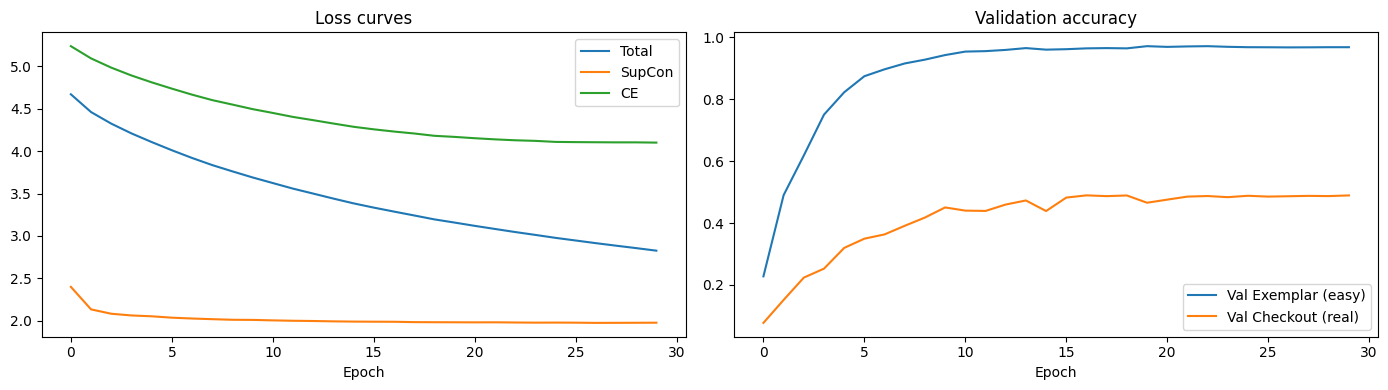

In [7]:
# ============================================================
# CELL 7: Training loop
# FIX: criterion.set_epoch(epoch) called each epoch for
#      alpha scheduling.
# FIX: val is measured on BOTH val_exemplar AND val_checkout
#      to show the real distribution gap.
# ============================================================
EPOCHS = 30
LR     = 2e-5

optimizer = AdamW([
    {'params': model.vit.parameters(),        'lr': LR},
    {'params': model.projector.parameters(),  'lr': LR * 10},
    {'params': model.classifier.parameters(), 'lr': LR * 10},
], weight_decay=1e-4)

scheduler    = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-7)
best_val_acc = 0.0
history      = defaultdict(list)


def eval_loader(loader, name):
    """Evaluate using classifier head (fast) on any loader."""
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            _, logits    = model(imgs)
            correct += (logits.argmax(1) == labels).sum().item()
            total   += len(labels)
    acc = correct / total if total > 0 else 0
    return acc


for epoch in range(EPOCHS):
    criterion.set_epoch(epoch)   # FIX: update alpha schedule
    model.train()
    total_loss = total_sc = total_ce = 0
    correct = total = 0

    for imgs, labels in tqdm(train_loader,
                              desc=f'Ep {epoch+1}/{EPOCHS}', leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        embeds, logits = model(imgs)
        loss, sc, ce   = criterion(embeds, logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()
        total_sc   += sc
        total_ce   += ce
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += len(labels)

    scheduler.step()
    train_acc     = correct / total

    # Evaluate on both splits every epoch
    val_ex_acc    = eval_loader(val_exemplar_loader,  'val_exemplar')
    val_co_acc    = eval_loader(val_checkout_loader,  'val_checkout')

    n = len(train_loader)
    alpha = criterion.current_alpha
    print(f'Ep {epoch+1:02d} | Loss {total_loss/n:.4f} '
          f'(SC:{total_sc/n:.4f} CE:{total_ce/n:.4f} α:{alpha:.2f}) | '
          f'Train:{train_acc:.4f} | ValEx:{val_ex_acc:.4f} | ValCO:{val_co_acc:.4f}')

    history['train_loss'].append(total_loss/n)
    history['val_ex_acc'].append(val_ex_acc)
    history['val_co_acc'].append(val_co_acc)
    history['sc_loss'].append(total_sc/n)
    history['ce_loss'].append(total_ce/n)

    # Save best based on CHECKOUT accuracy (the real target)
    if val_co_acc > best_val_acc:
        best_val_acc = val_co_acc
        torch.save(model.state_dict(), f'{WORK_ROOT}/vit_sku_best.pt')
        print(f'  ✓ Saved (checkout_val_acc={val_co_acc:.4f})')

print(f'\nBest checkout val acc: {best_val_acc:.4f}')
print('ValEx = exemplar-style (clean, easy) | ValCO = checkout-style (real)')

# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(history['train_loss'], label='Total')
ax1.plot(history['sc_loss'],    label='SupCon')
ax1.plot(history['ce_loss'],    label='CE')
ax1.set_title('Loss curves'); ax1.legend(); ax1.set_xlabel('Epoch')
ax2.plot(history['val_ex_acc'],  label='Val Exemplar (easy)')
ax2.plot(history['val_co_acc'],  label='Val Checkout (real)')
ax2.set_title('Validation accuracy'); ax2.legend(); ax2.set_xlabel('Epoch')
plt.tight_layout()
plt.savefig(f'{WORK_ROOT}/training_curves.png', dpi=130)
plt.show()

In [8]:
# ============================================================
# CELL 8: Build gallery (from train_gallery only)
# ============================================================
model.load_state_dict(torch.load(f'{WORK_ROOT}/vit_sku_best.pt', map_location=DEVICE))
model.eval()

gallery_sums   = defaultdict(lambda: torch.zeros(EMBED_DIM))
gallery_counts = defaultdict(int)

gallery_ds = SKUCropDataset(f'{CROP_DIR}/train_gallery', cat_to_label, val_tf)
with torch.no_grad():
    for imgs, labels in tqdm(
            DataLoader(gallery_ds, batch_size=64, shuffle=False, num_workers=2),
            desc='Building gallery'):
        embeds = model(imgs.to(DEVICE), return_embed=True).cpu()
        for emb, lbl in zip(embeds, labels.numpy()):
            lbl = int(lbl)
            gallery_sums[lbl]   += emb
            gallery_counts[lbl] += 1

gallery_matrix = []
gallery_labels = []
for lbl in sorted(gallery_sums.keys()):
    mean_emb = F.normalize(gallery_sums[lbl] / gallery_counts[lbl], p=2, dim=0)
    gallery_matrix.append(mean_emb)
    gallery_labels.append(lbl)

gallery_matrix = torch.stack(gallery_matrix).to(DEVICE)
gallery_labels = torch.tensor(gallery_labels).to(DEVICE)

sku_class_to_indices = defaultdict(list)
for idx, lbl in enumerate(gallery_labels.cpu().tolist()):
    cat_id = label_to_cat[lbl]
    sku_class_to_indices[sku_lookup.get(cat_id, {}).get('sku_class', 'unknown')].append(idx)

print(f'Gallery: {gallery_matrix.shape}')
for k, v in sorted(sku_class_to_indices.items()):
    print(f'  {k}: {len(v)} SKUs')

torch.save({'matrix': gallery_matrix.cpu(), 'labels': gallery_labels.cpu(),
            'sku_class_to_indices': dict(sku_class_to_indices)},
           f'{WORK_ROOT}/sku_gallery.pt')
print(f'Saved → {WORK_ROOT}/sku_gallery.pt')

Dataset [train_gallery]: 11200 samples, 200 classes


Building gallery: 100%|██████████| 175/175 [00:51<00:00,  3.39it/s]

Gallery: torch.Size([200, 128])
  alcohol: 11 SKUs
  candy: 10 SKUs
  canned_food: 14 SKUs
  chocolate: 12 SKUs
  dessert: 17 SKUs
  dried_food: 9 SKUs
  dried_fruit: 9 SKUs
  drink: 15 SKUs
  gum: 8 SKUs
  instant_drink: 11 SKUs
  instant_noodles: 12 SKUs
  milk: 11 SKUs
  personal_hygiene: 10 SKUs
  puffed_food: 12 SKUs
  seasoner: 12 SKUs
  stationery: 7 SKUs
  tissue: 20 SKUs
Saved → /kaggle/working/sku_gallery.pt


In [ ]:
# ============================================================
# CELL 9: OCR engine
# ============================================================
import paddleocr

_ocr_reader = None

def get_ocr_reader():
    global _ocr_reader
    if _ocr_reader is None:
        print('Loading paddleOCR...')
        _ocr_reader = paddleocr.Reader(['ch_sim', 'en'], gpu=torch.cuda.is_available())
        print('paddleOCR ready.')
    return _ocr_reader


def _build_sku_text_index():
    idx = defaultdict(set)
    for cat_id, info in sku_lookup.items():
        name = info.get('name', '')
        for length in range(2, min(len(name)+1, 6)):
            for start in range(len(name) - length + 1):
                idx[name[start:start+length]].add(cat_id)
        for cn in BRAND_MAP:
            if cn in name:
                idx[cn].add(cat_id)
        code = str(info.get('code', ''))
        if code.isdigit() and len(code) >= 4:
            idx[code].add(cat_id)
    return dict(idx)

_sku_text_index = _build_sku_text_index()


def ocr_identify(crop_rgb):
    """Returns (cat_id, score, ocr_text) or (None, 0, '')."""
    reader  = get_ocr_reader()
    results = reader.readtext(crop_rgb, detail=0, paragraph=True)
    if not results:
        return None, 0, ''
    all_text = ' '.join(results)
    scores   = defaultdict(int)
    for token, cat_ids in _sku_text_index.items():
        if token in all_text:
            for cid in cat_ids:
                scores[cid] += len(token)
    if not scores:
        return None, 0, all_text
    best_cat = max(scores, key=scores.get)
    return best_cat, scores[best_cat], all_text


print(f'OCR engine ready. Index size: {len(_sku_text_index)} tokens')

OCR engine ready. Index size: 9458 tokens


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

0: 640x640 2 chocolates, 1 instant_noodles, 2 milks, 2 personal_hygienes, 2 puffed_foods, 1 stationery, 62.6ms
Speed: 14.0ms preprocess, 62.6ms inference, 5.3ms postprocess per image at shape (1, 3, 640, 640)
Loading EasyOCR...


Progress: |██████████████████████████████████████████████████| 100.0% CompleteEasyOCR ready.


/tmp/ipykernel_21/3095771787.py:197: UserWarning: Glyph 33284 (\N{CJK UNIFIED IDEOGRAPH-8204}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_21/3095771787.py:197: UserWarning: Glyph 19978 (\N{CJK UNIFIED IDEOGRAPH-4E0A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_21/3095771787.py:197: UserWarning: Glyph 20339 (\N{CJK UNIFIED IDEOGRAPH-4F73}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_21/3095771787.py:197: UserWarning: Glyph 33300 (\N{CJK UNIFIED IDEOGRAPH-8214}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_21/3095771787.py:197: UserWarning: Glyph 25776 (\N{CJK UNIFIED IDEOGRAPH-64B0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_21/3095771787.py:197: UserWarning: Glyph 22549 (\N{CJK UNIFIED IDEOGRAPH-5815}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_21/3095771787.py:197: UserWarning: Glyph 31932 (\N{CJK UNIFIED IDEOGRAPH-7CBC}) missi

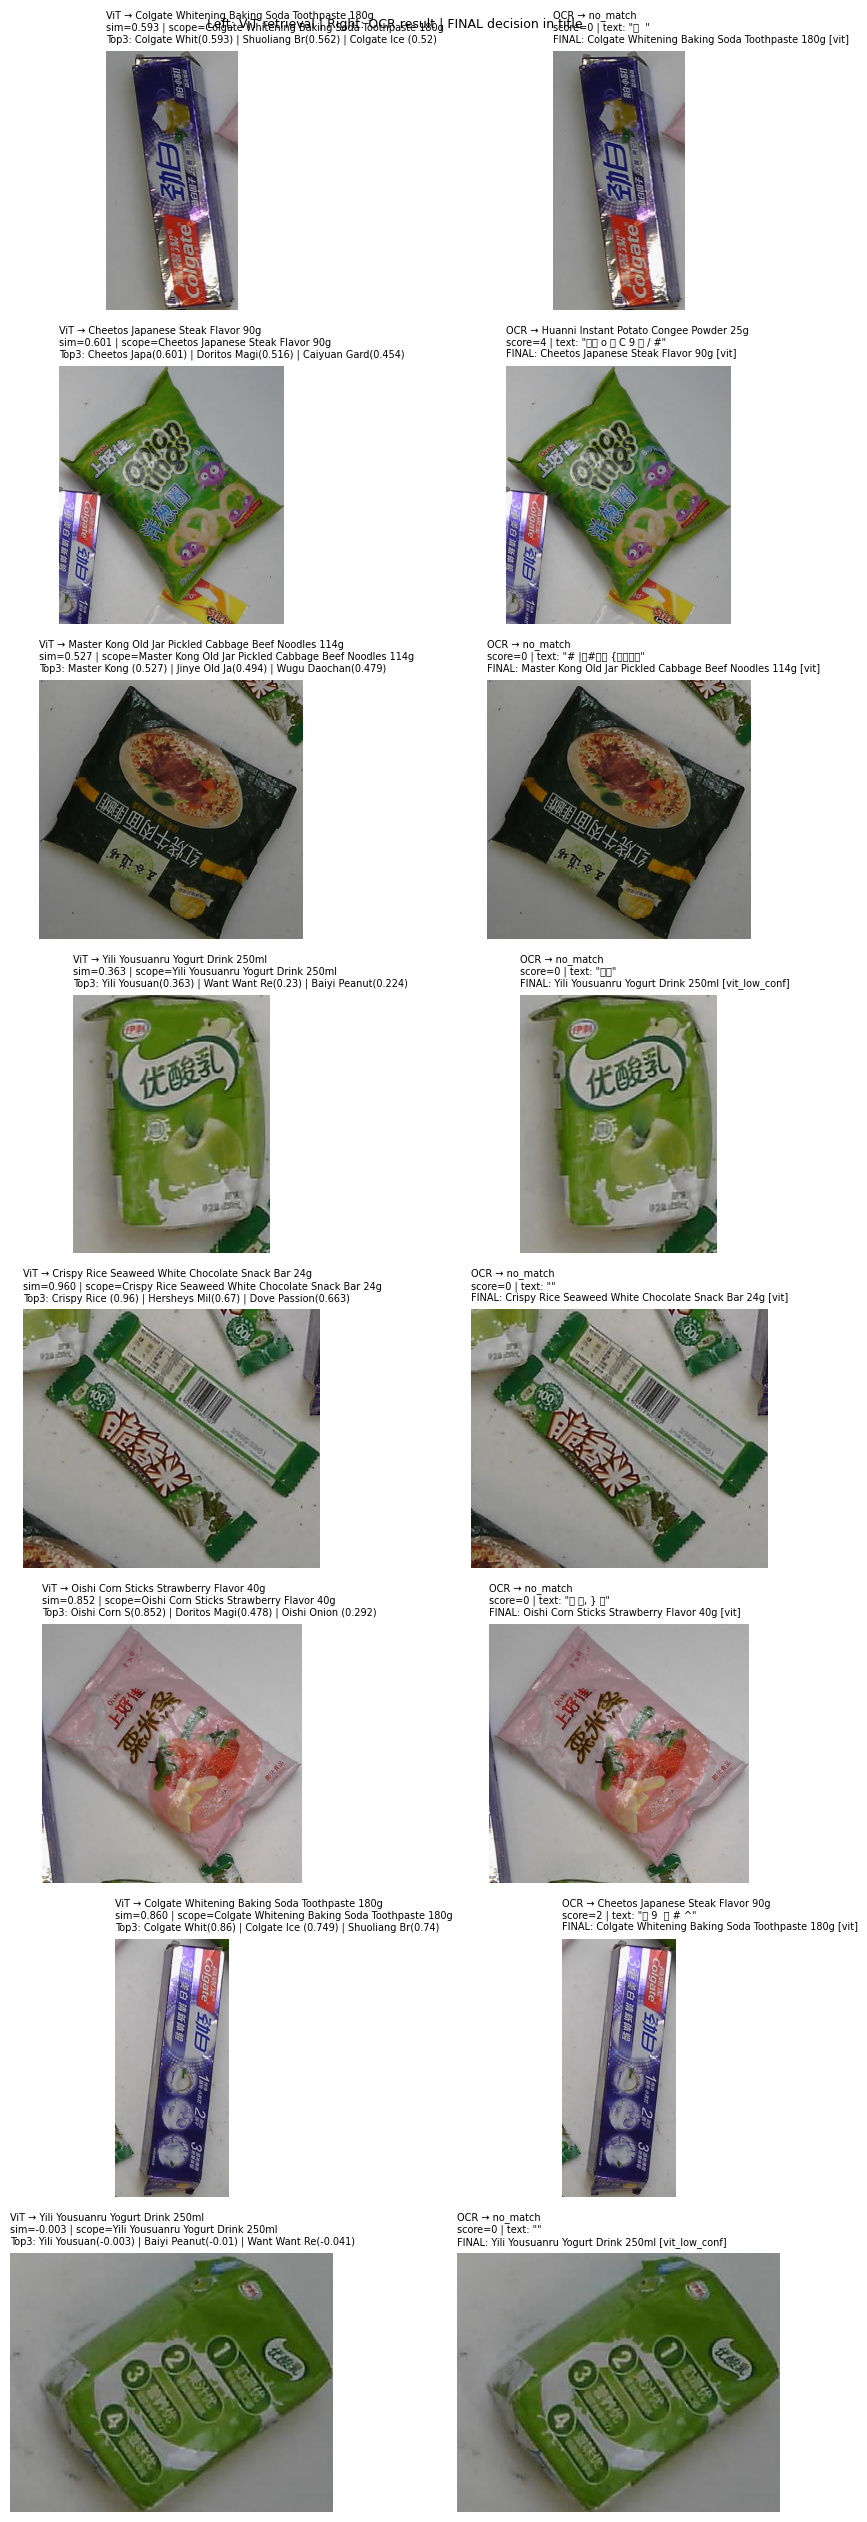


SKU counts:
  2×  Colgate Whitening Baking Soda Toothpaste 180g
  2×  Yili Yousuanru Yogurt Drink 250ml
  2×  Crispy Rice Seaweed White Chocolate Snack Bar 24g
  1×  Cheetos Japanese Steak Flavor 90g
  1×  Master Kong Old Jar Pickled Cabbage Beef Noodles 114g
  1×  Oishi Corn Sticks Strawberry Flavor 40g
  1×  Stride Spearmint Chewing Gum 21g

Per-box (ViT vs OCR comparison):
#   Category       ViT Result                   ViT sim  OCR Result                   OCR score  Final
--------------------------------------------------------------------------------------------------------------
1   personal_hygiene Colgate Whitening Baking So  0.593    no_match                     0          vit
2   puffed_food    Cheetos Japanese Steak Flav  0.601    Huanni Instant Potato Conge  4          vit
3   instant_noodles Master Kong Old Jar Pickled  0.527    no_match                     0          vit
4   milk           Yili Yousuanru Yogurt Drink  0.363    no_match                     0          vit

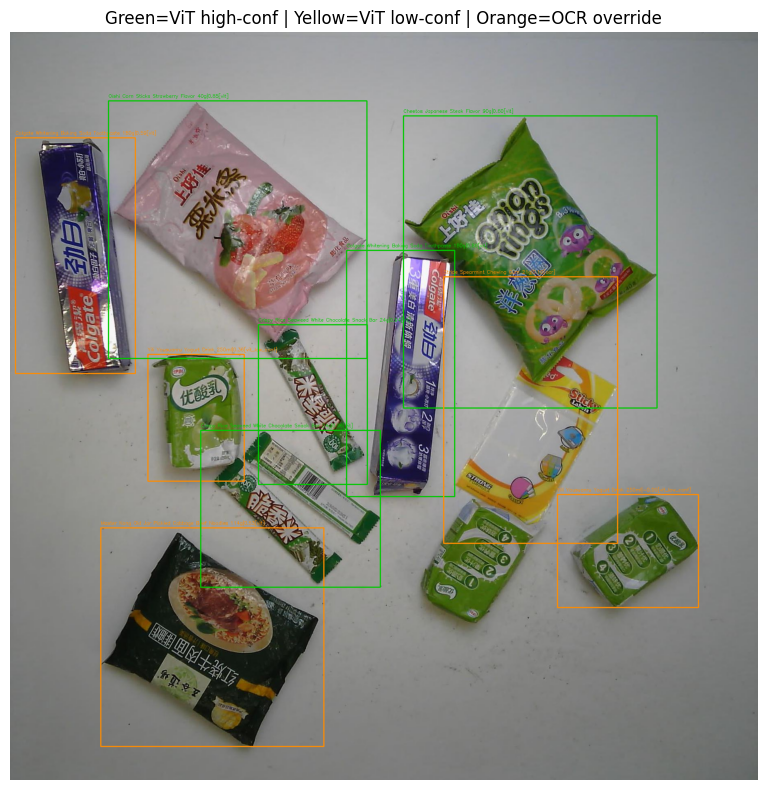

In [10]:
# ============================================================
# CELL 10: Full inference pipeline
# NEW: identify_with_fallback now returns BOTH ViT AND OCR
#      results so you can compare them side by side.
# NEW: predict_full renders a 3-column display:
#      crop | ViT result | OCR result
# ============================================================
!pip install -q ultralytics
from ultralytics import YOLO

yolo_model = YOLO('/kaggle/input/datasets/melodysha/yolov8l-train-rpc/best.pt')

model.load_state_dict(torch.load(f'{WORK_ROOT}/vit_sku_best.pt', map_location=DEVICE))
model.eval()

gallery = torch.load(f'{WORK_ROOT}/sku_gallery.pt')
g_matrix             = gallery['matrix'].to(DEVICE)
g_labels             = gallery['labels'].to(DEVICE)
sku_class_to_indices = gallery['sku_class_to_indices']


def embed_with_tta(crop_rgb, enabled=True):
    tfs = tta_transforms if enabled else [val_tf]
    embeds = []
    with torch.no_grad():
        for tf in tfs:
            emb = model(tf(crop_rgb).unsqueeze(0).to(DEVICE), return_embed=True)
            embeds.append(emb)
    return F.normalize(torch.stack(embeds).mean(dim=0), p=2, dim=1)


def vit_retrieve(embed, yolo_class, top_k=3):
    """Pure ViT cosine retrieval. Always returns a result."""
    cat_idxs = sku_class_to_indices.get(yolo_class, [])
    if len(cat_idxs) >= top_k:
        sub_m  = g_matrix[cat_idxs]
        sims   = torch.matmul(embed, sub_m.T).squeeze(0)
        top_sims, top_local = sims.topk(min(top_k, len(cat_idxs)))
        top_idxs = [cat_idxs[i] for i in top_local.cpu().tolist()]
        scope = f'filtered({len(cat_idxs)})'
    else:
        sims   = torch.matmul(embed, g_matrix.T).squeeze(0)
        top_sims, top_idxs_t = sims.topk(top_k)
        top_idxs = top_idxs_t.cpu().tolist()
        scope = 'full_gallery'

    best_idx  = top_idxs[0]
    best_sim  = top_sims[0].item()
    cat_id    = label_to_cat[g_labels[best_idx].item()]
    meta      = sku_lookup.get(cat_id, {})
    top_k_res = [
        {'sku': sku_lookup.get(label_to_cat[g_labels[i].item()], {}).get('name', '?'),
         'sim': round(top_sims[j].item(), 3)}
        for j, i in enumerate(top_idxs)
    ]
    return {'cat_id': cat_id, 'meta': meta, 'sim': round(best_sim, 3),
            'top_k': top_k_res, 'scope': scope}


def identify_dual(crop_rgb, yolo_class, top_k=3):
    """
    NEW: Returns BOTH ViT result AND OCR result independently.
    Final decision:
      - If ViT sim >= OCR_FALLBACK_SIM → use ViT
      - Else if OCR score >= 4 → use OCR
      - Else → use ViT anyway (never Unknown)

    Returns dict with keys:
      vit_result  : full ViT retrieval dict
      ocr_result  : full OCR dict (cat_id, score, raw_text)
      final_result: chosen result
      method      : 'vit' or 'ocr'
    """
    embed      = embed_with_tta(crop_rgb, enabled=TTA_ENABLED)
    vit        = vit_retrieve(embed, yolo_class, top_k)

    # Always run OCR so both outputs are always available
    ocr_cat, ocr_score, ocr_text = ocr_identify(crop_rgb)
    ocr_meta = sku_lookup.get(ocr_cat, {}) if ocr_cat else {}
    ocr_result = {
        'cat_id':   ocr_cat,
        'meta':     ocr_meta,
        'score':    ocr_score,
        'raw_text': ocr_text,
        'name':     ocr_meta.get('name', 'no_match') if ocr_meta else 'no_match',
    }

    # Decision logic
    if vit['sim'] >= OCR_FALLBACK_SIM:
        method = 'vit'
        final  = vit
    elif ocr_cat is not None and ocr_score >= 4:
        method = 'ocr'
        final  = {'cat_id': ocr_cat, 'meta': ocr_meta,
                  'sim': vit['sim'], 'top_k': vit['top_k'], 'scope': 'ocr_override'}
    else:
        method = 'vit_low_conf'
        final  = vit  # use ViT anyway — never Unknown

    return {'vit_result': vit, 'ocr_result': ocr_result,
            'final_result': final, 'method': method}


def predict_full(image_path, yolo_conf=0.3, top_k=3, show_detail=True):
    image  = cv2.imread(image_path)
    canvas = image.copy()

    det        = yolo_model(image, conf=yolo_conf, iou=0.45)[0]
    output     = []
    sku_counts = {}
    crop_details = []  # for side-by-side ViT vs OCR display

    for box in det.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        yolo_class      = yolo_model.names[int(box.cls)]
        yolo_conf_val   = float(box.conf)
        w, h = x2-x1, y2-y1

        if yolo_conf_val < YOLO_CONF_MIN: continue
        if w < CROP_MIN_PX or h < CROP_MIN_PX: continue
        if not (ASPECT_MIN <= w/max(h,1) <= ASPECT_MAX): continue
        crop = image[y1:y2, x1:x2]
        if crop.size == 0: continue

        crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
        dual     = identify_dual(crop_rgb, yolo_class, top_k)
        final    = dual['final_result']
        method   = dual['method']
        meta     = final['meta']

        sku_name = meta.get('name', '?')
        brand    = meta.get('brand', sku_name)
        sku_counts[sku_name] = sku_counts.get(sku_name, 0) + 1

        r = {
            'supercategory': yolo_class,
            'brand':         brand,
            'sku_name':      sku_name,
            'category_id':   final['cat_id'],
            'yolo_conf':     round(yolo_conf_val, 3),
            'method':        method,
            # ViT specific
            'vit_name':      dual['vit_result']['meta'].get('name', '?'),
            'vit_sim':       dual['vit_result']['sim'],
            'vit_top3':      dual['vit_result']['top_k'],
            # OCR specific
            'ocr_name':      dual['ocr_result']['name'],
            'ocr_score':     dual['ocr_result']['score'],
            'ocr_text':      dual['ocr_result']['raw_text'],
        }
        output.append(r)
        crop_details.append((crop_rgb, r))

        # Bounding box colour: green=ViT confident, yellow=low conf, orange=OCR
        color = {True: (0,200,0), False: (0,140,255)}.get(method=='vit' and final['sim']>=0.6,
                  (0,165,255) if method!='ocr' else (0,100,255))
        cv2.rectangle(canvas, (x1,y1), (x2,y2), color, 2)
        cv2.putText(canvas, f"{brand}|{final['sim']:.2f}[{method}]",
                    (x1, max(y1-8, 0)), cv2.FONT_HERSHEY_SIMPLEX, 0.38, color, 1)

    if show_detail and crop_details:
        _show_dual_results(crop_details[:8])  # show up to 8

    return canvas, {'per_box': output, 'sku_counts': sku_counts}


def _show_dual_results(crop_details):
    """Display each crop with ViT result and OCR result side by side."""
    n   = len(crop_details)
    fig, axes = plt.subplots(n, 2, figsize=(10, 3.2 * n))
    if n == 1: axes = [axes]

    for i, (crop_rgb, r) in enumerate(crop_details):
        # Left: crop + ViT result
        axes[i][0].imshow(crop_rgb)
        axes[i][0].set_title(
            f'ViT → {r["vit_name"]}\n'
            f'sim={r["vit_sim"]:.3f} | scope={r["vit_top3"][0]["sku"]}\n'
            f'Top3: ' + ' | '.join(f'{x["sku"][:12]}({x["sim"]})'
                                    for x in r['vit_top3']),
            fontsize=7, loc='left'
        )
        axes[i][0].axis('off')

        # Right: OCR result
        axes[i][1].imshow(crop_rgb)
        ocr_display = (
            f'OCR → {r["ocr_name"]}\n'
            f'score={r["ocr_score"]} | text: "{r["ocr_text"][:40]}"\n'
            f'FINAL: {r["sku_name"]} [{r["method"]}]'
        )
        axes[i][1].set_title(ocr_display, fontsize=7, loc='left')
        axes[i][1].axis('off')

    plt.suptitle('Left: ViT retrieval | Right: OCR result | FINAL decision in title',
                 fontsize=9)
    plt.tight_layout()
    plt.savefig(f'{WORK_ROOT}/vit_vs_ocr.png', dpi=130, bbox_inches='tight')
    plt.show()


# ── Test on a checkout scene ──────────────────────────────────
TEST_IMG = f'{DATA_ROOT}/val2019/20181024-16-49-05-181.jpg'
out_img, summary = predict_full(TEST_IMG, top_k=3)

print('\nSKU counts:')
for sku, cnt in sorted(summary['sku_counts'].items(), key=lambda x: -x[1]):
    print(f'  {cnt}×  {sku}')

print('\nPer-box (ViT vs OCR comparison):')
print(f'{"#":<3} {"Category":<14} {"ViT Result":<28} {"ViT sim":<8} {"OCR Result":<28} {"OCR score":<10} {"Final"}')
print('-'*110)
for i, d in enumerate(summary['per_box']):
    print(f'{i+1:<3} {d["supercategory"]:<14} '
          f'{d["vit_name"][:27]:<28} {d["vit_sim"]:<8} '
          f'{d["ocr_name"][:27]:<28} {d["ocr_score"]:<10} '
          f'{d["method"]}')

unknowns = [d for d in summary['per_box'] if d['sku_name'] in ('?','')]
print(f'\nUnknown count: {len(unknowns)} (target: 0)')

plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(out_img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Green=ViT high-conf | Yellow=ViT low-conf | Orange=OCR override')
plt.tight_layout()
plt.savefig(f'{WORK_ROOT}/inference_result.png', dpi=130)
plt.show()

In [11]:
# ============================================================
# CELL 11: Honest evaluation on THREE splits
# 1. val_exemplar  — clean train-style crops (easy)
# 2. val_checkout  — checkout scene crops (real difficulty)
# 3. test_checkout — final held-out test (report this number)
# ============================================================
from sklearn.metrics import classification_report


def evaluate_retrieval(loader, loader_name, g_mat, g_lbls):
    """Cosine-retrieval accuracy on any loader."""
    all_preds, all_labels = [], []
    all_embeds_list       = []
    model.eval()
    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc=f'Eval {loader_name}'):
            imgs   = imgs.to(DEVICE)
            embeds = model(imgs, return_embed=True)
            sims   = torch.matmul(embeds, g_mat.T)
            preds  = g_lbls[sims.argmax(dim=1)].cpu()

            all_preds.extend([label_to_cat[p.item()] for p in preds])
            all_labels.extend([label_to_cat[l.item()] for l in labels])
            all_embeds_list.append(embeds.cpu())

    top1 = sum(p==l for p,l in zip(all_preds, all_labels)) / len(all_labels)

    # Top-5
    top5_correct = 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs   = imgs.to(DEVICE)
            embeds = model(imgs, return_embed=True)
            sims   = torch.matmul(embeds, g_mat.T)
            top5   = sims.topk(5, dim=1).indices
            top5_lbls = g_lbls[top5]
            top5_correct += (top5_lbls == labels.to(DEVICE).unsqueeze(1)).any(dim=1).sum().item()
    top5 = top5_correct / len(loader.dataset)

    print(f'\n[{loader_name}] Top-1: {top1:.4f} | Top-5: {top5:.4f}')

    # Per-category breakdown
    df = pd.DataFrame({'category_id': all_labels, 'predicted': all_preds})
    df['sku_class'] = df['category_id'].map(lambda x: sku_lookup.get(x,{}).get('sku_class','?'))
    df['correct']   = df['category_id'] == df['predicted']
    cat_acc = (df.groupby('sku_class')['correct']
               .agg(['sum','count','mean'])
               .rename(columns={'sum':'correct','count':'total','mean':'acc'})
               .sort_values('acc'))
    print(cat_acc.to_string())

    # Worst individual SKUs
    df['sku_name'] = df['category_id'].map(lambda x: sku_lookup.get(x,{}).get('name', str(x)))
    worst = (df.groupby('sku_name')['correct']
               .agg(['sum','count','mean'])
               .rename(columns={'sum':'correct','count':'total','mean':'acc'})
               .sort_values('acc').head(15))
    print(f'Worst 15 SKUs on {loader_name}:')
    print(worst.to_string())

    return top1, top5, torch.cat(all_embeds_list, dim=0), all_labels


print('='*60)
print('Evaluation on val_exemplar (clean single-product crops):')
top1_ex, top5_ex, embeds_ex, lbls_ex = evaluate_retrieval(
    val_exemplar_loader, 'val_exemplar', g_matrix, g_labels)

print('='*60)
print('Evaluation on val_checkout (real checkout scene crops):')
top1_co, top5_co, embeds_co, lbls_co = evaluate_retrieval(
    val_checkout_loader, 'val_checkout', g_matrix, g_labels)

print('='*60)
print('FINAL TEST on test_checkout (report this in your paper):')
top1_te, top5_te, embeds_te, lbls_te = evaluate_retrieval(
    test_checkout_loader, 'test_checkout', g_matrix, g_labels)

print('\n' + '='*60)
print(f'SUMMARY:')
print(f'  val_exemplar  Top1={top1_ex:.4f} Top5={top5_ex:.4f}  ← easy, inflated')
print(f'  val_checkout  Top1={top1_co:.4f} Top5={top5_co:.4f}  ← real difficulty')
print(f'  test_checkout Top1={top1_te:.4f} Top5={top5_te:.4f}  ← paper number')

Evaluation on val_exemplar (clean single-product crops):


Eval val_exemplar: 100%|██████████| 75/75 [00:21<00:00,  3.50it/s]



[val_exemplar] Top-1: 0.9892 | Top-5: 0.9931
                  correct  total       acc
sku_class                                 
milk                  254    264  0.962121
drink                 348    360  0.966667
alcohol               257    264  0.973485
instant_drink         259    264  0.981061
canned_food           331    336  0.985119
instant_noodles       284    288  0.986111
stationery            166    168  0.988095
gum                   191    192  0.994792
candy                 239    240  0.995833
personal_hygiene      239    240  0.995833
tissue                478    480  0.995833
seasoner              287    288  0.996528
dessert               407    408  0.997549
dried_fruit           216    216  1.000000
chocolate             288    288  1.000000
dried_food            216    216  1.000000
puffed_food           288    288  1.000000
Worst 15 SKUs on val_exemplar:
                                                             correct  total       acc
sku_name            

Eval val_checkout: 100%|██████████| 94/94 [00:25<00:00,  3.67it/s]



[val_checkout] Top-1: 0.5038 | Top-5: 0.6873
                  correct  total       acc
sku_class                                 
dried_fruit            87    270  0.322222
milk                  132    330  0.400000
stationery             85    210  0.404762
instant_drink         138    330  0.418182
seasoner              157    360  0.436111
gum                   109    240  0.454167
canned_food           192    420  0.457143
alcohol               158    330  0.478788
drink                 217    450  0.482222
instant_noodles       178    360  0.494444
puffed_food           182    360  0.505556
tissue                322    600  0.536667
dried_food            145    270  0.537037
personal_hygiene      171    300  0.570000
chocolate             224    360  0.622222
dessert               323    510  0.633333
candy                 203    300  0.676667
Worst 15 SKUs on val_checkout:
                                                       correct  total       acc
sku_name                  

Eval test_checkout: 100%|██████████| 94/94 [00:26<00:00,  3.57it/s]



[test_checkout] Top-1: 0.5145 | Top-5: 0.6905
                  correct  total       acc
sku_class                                 
dried_fruit            86    270  0.318519
stationery             87    210  0.414286
drink                 192    450  0.426667
milk                  142    330  0.430303
instant_drink         147    330  0.445455
seasoner              162    360  0.450000
canned_food           198    420  0.471429
instant_noodles       175    360  0.486111
alcohol               168    330  0.509091
gum                   124    240  0.516667
tissue                321    600  0.535000
puffed_food           194    360  0.538889
dried_food            153    270  0.566667
personal_hygiene      183    300  0.610000
chocolate             224    360  0.622222
dessert               332    510  0.650980
candy                 199    300  0.663333
Worst 15 SKUs on test_checkout:
                                                       correct  total       acc
sku_name                

Embedding stats on checkout_val:
  Intra-class dist : 0.3795
  Inter-class dist : 0.8829
  Separation ratio : 2.33
  Silhouette score : 0.1078


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


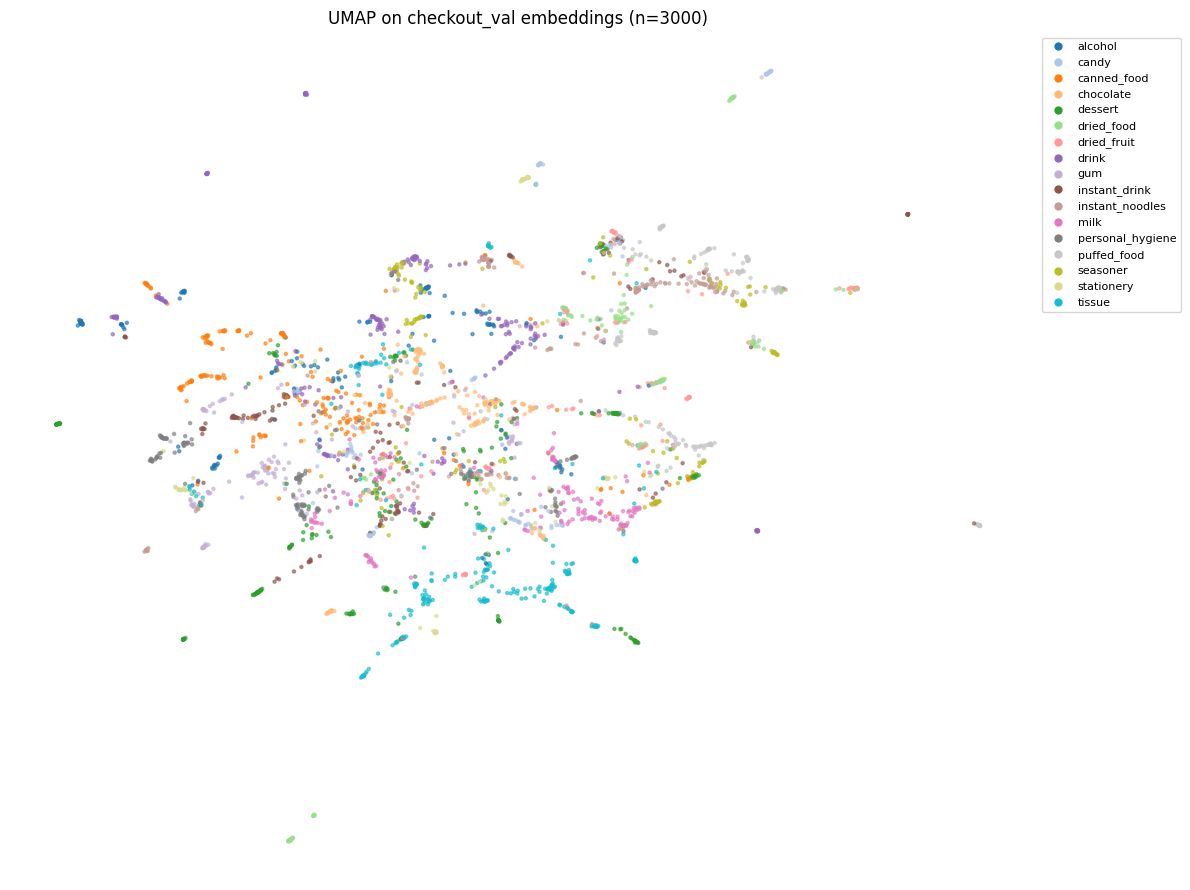

In [12]:
# ============================================================
# CELL 12: Embedding space analysis (on checkout val)
# ============================================================
from sklearn.metrics import silhouette_score

all_embeds    = embeds_co.numpy()
all_label_arr = np.array(lbls_co)

print('Embedding stats on checkout_val:')
unique_cats = np.unique(all_label_arr)
intra_dists, inter_sample = [], []
rng = np.random.default_rng(42)

for cat in unique_cats:
    vecs = all_embeds[all_label_arr == cat]
    if len(vecs) < 2: continue
    sim_mat = cosine_similarity(vecs)
    np.fill_diagonal(sim_mat, np.nan)
    intra_dists.append(np.nanmean(1 - sim_mat))

for _ in range(500):
    c1, c2 = rng.choice(list(unique_cats), 2, replace=False)
    v1, v2 = all_embeds[all_label_arr==c1][0], all_embeds[all_label_arr==c2][0]
    inter_sample.append(1 - float(cosine_similarity(v1[None], v2[None]).item()))

print(f'  Intra-class dist : {np.mean(intra_dists):.4f}')
print(f'  Inter-class dist : {np.mean(inter_sample):.4f}')
print(f'  Separation ratio : {np.mean(inter_sample)/np.mean(intra_dists):.2f}')

sn = min(2000, len(all_embeds))
ix = rng.choice(len(all_embeds), sn, replace=False)
sil = silhouette_score(all_embeds[ix], all_label_arr[ix], metric='cosine')
print(f'  Silhouette score : {sil:.4f}')

# UMAP/t-SNE
sn2  = min(3000, len(all_embeds))
ix2  = rng.choice(len(all_embeds), sn2, replace=False)
if HAS_UMAP:
    proj = umap.UMAP(n_components=2, metric='cosine', random_state=42
                    ).fit_transform(all_embeds[ix2])
    mth  = 'UMAP'
else:
    proj = TSNE(n_components=2, metric='cosine', random_state=42
               ).fit_transform(all_embeds[ix2])
    mth  = 't-SNE'

supercats = [sku_lookup.get(all_label_arr[i], {}).get('sku_class','?') for i in ix2]
unique_sc = sorted(set(supercats))
cmap      = plt.colormaps.get_cmap('tab20')
sc_color  = {sc: cmap(i/len(unique_sc)) for i,sc in enumerate(unique_sc)}

fig, ax = plt.subplots(figsize=(12, 9))
ax.scatter(proj[:,0], proj[:,1], c=[sc_color[s] for s in supercats], s=5, alpha=0.6)
ax.legend(handles=[plt.Line2D([0],[0],marker='o',color='w',
                               markerfacecolor=sc_color[sc],markersize=7,label=sc)
                   for sc in unique_sc],
          bbox_to_anchor=(1.01,1), loc='upper left', fontsize=8)
ax.set_title(f'{mth} on checkout_val embeddings (n={sn2})', fontsize=12)
ax.axis('off')
plt.tight_layout()
plt.savefig(f'{WORK_ROOT}/embedding_{mth.lower()}.png', dpi=130, bbox_inches='tight')
plt.show()


0: 640x640 4 candys, 1 canned_food, 1 chocolate, 1 drink, 1 instant_drink, 1 instant_noodles, 2 puffed_foods, 1 seasoner, 62.6ms
Speed: 4.0ms preprocess, 62.6ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)


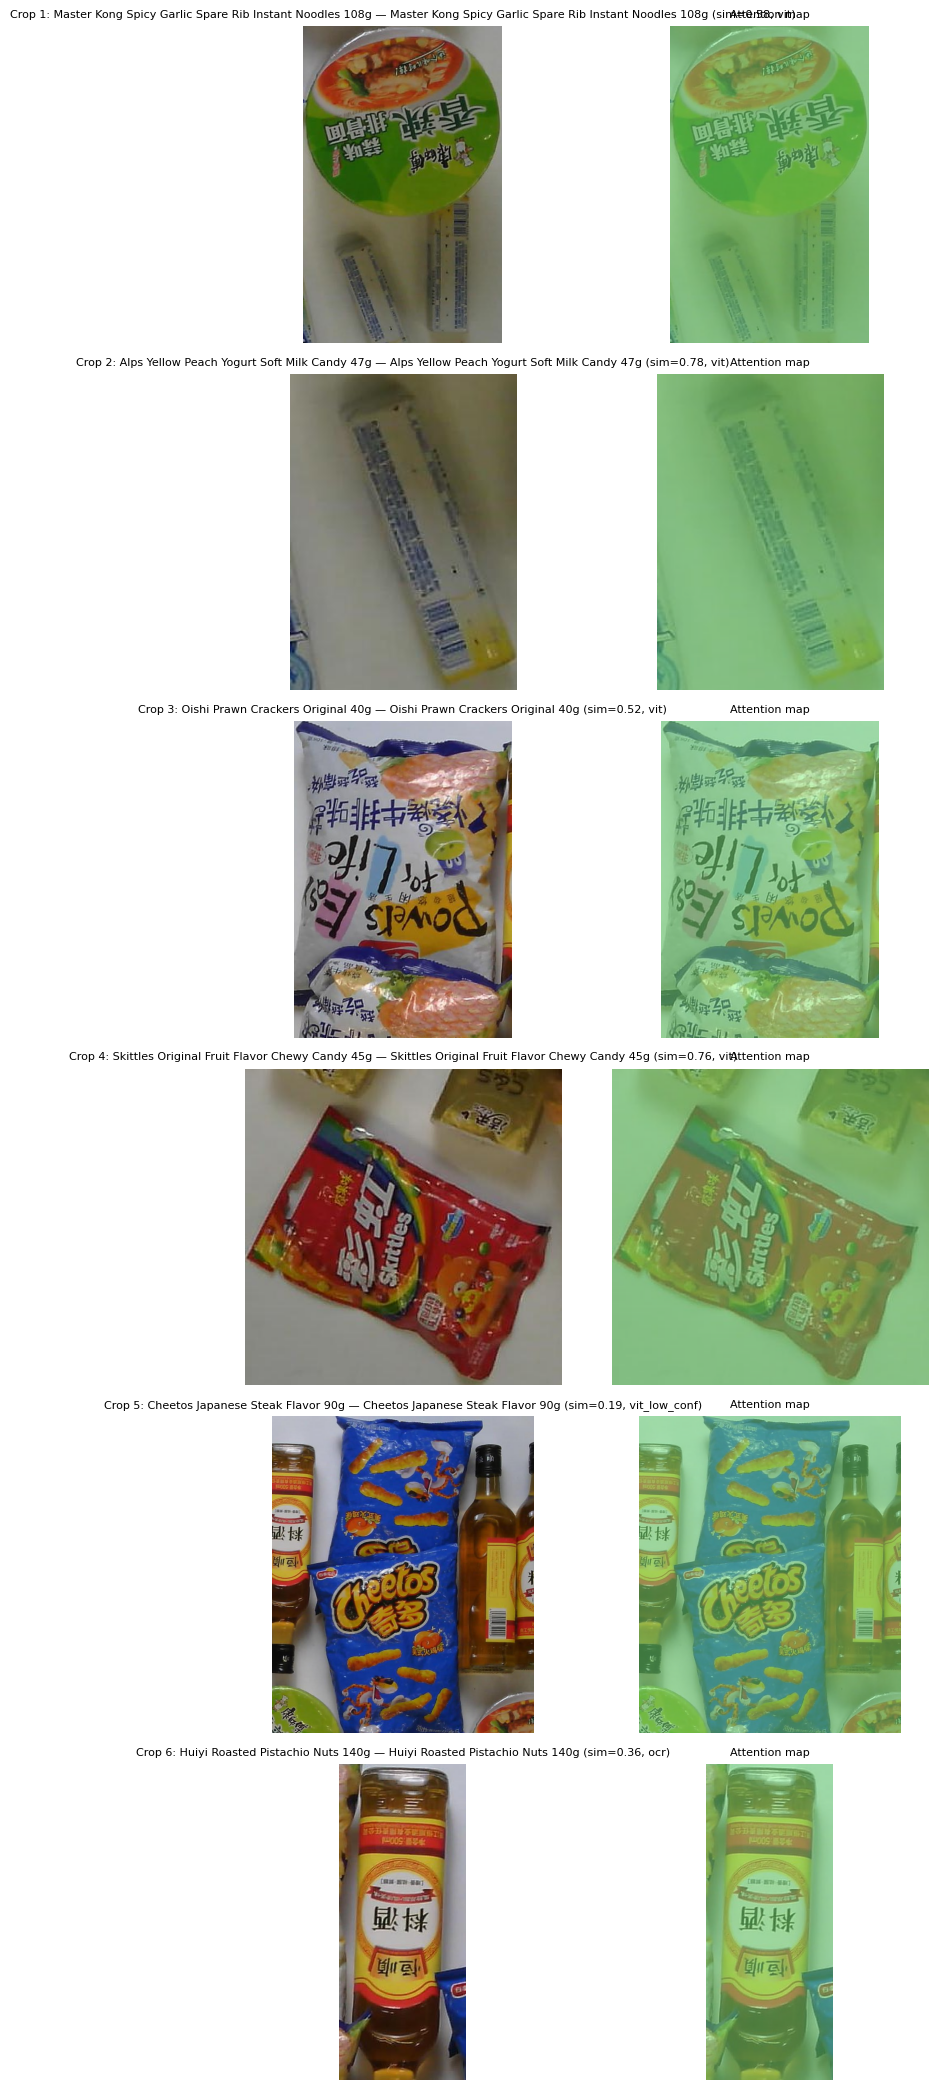

In [13]:
# ============================================================
# CELL 13: Attention visualization (unchanged)
# ============================================================

def get_attention_map(crop_rgb):
    tensor = val_tf(crop_rgb).unsqueeze(0).to(DEVICE)
    model.eval()
    with torch.no_grad():
        _, attentions = model(tensor, return_attentions=True)
    if not attentions:
        # ViT did not return attention weights (config may not support it).
        # Return a uniform heatmap so the visualisation still runs.
        h, w = crop_rgb.shape[:2]
        return np.ones((h, w), dtype=np.float32) * 0.5
    last_attn = attentions[-1][0].mean(0)
    cls_attn  = last_attn[0, 1:]
    n_patch   = int(cls_attn.shape[0] ** 0.5)
    attn_map  = cls_attn.reshape(n_patch, n_patch).cpu().numpy()
    attn_map  = (attn_map - attn_map.min()) / (attn_map.max() - attn_map.min() + 1e-8)
    return cv2.resize(attn_map, (crop_rgb.shape[1], crop_rgb.shape[0]),
                      interpolation=cv2.INTER_LINEAR)


def visualize_attention(image_path, n_crops=6):
    image = cv2.imread(image_path)
    det   = yolo_model(image, conf=YOLO_CONF_MIN, iou=0.45)[0]

    boxes_valid = []
    for box in det.boxes:
        x1,y1,x2,y2 = map(int, box.xyxy[0])
        w,h = x2-x1, y2-y1
        if (float(box.conf)<YOLO_CONF_MIN or w<CROP_MIN_PX or h<CROP_MIN_PX
                or not (ASPECT_MIN <= w/max(h,1) <= ASPECT_MAX)):
            continue
        boxes_valid.append(box)
        if len(boxes_valid) >= n_crops: break

    if not boxes_valid:
        print('No valid crops.'); return

    n = len(boxes_valid)
    fig, axes = plt.subplots(n, 2, figsize=(8, 3.5*n))
    if n == 1: axes = [axes]

    for i, box in enumerate(boxes_valid):
        x1,y1,x2,y2 = map(int, box.xyxy[0])
        crop_rgb     = cv2.cvtColor(image[y1:y2, x1:x2], cv2.COLOR_BGR2RGB)
        attn_map     = get_attention_map(crop_rgb)

        heatmap = cv2.applyColorMap((attn_map*255).astype(np.uint8), cv2.COLORMAP_JET)
        overlay = (0.55*crop_rgb + 0.45*cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
                  ).astype(np.uint8)

        yolo_class  = yolo_model.names[int(box.cls)]
        dual        = identify_dual(crop_rgb, yolo_class)
        meta        = dual['final_result']['meta']
        label_str   = (f"{meta.get('brand','?')} — {meta.get('name','?')} "
                       f"(sim={dual['vit_result']['sim']:.2f}, {dual['method']})")

        axes[i][0].imshow(crop_rgb)
        axes[i][0].set_title(f'Crop {i+1}: {label_str}', fontsize=8)
        axes[i][0].axis('off')
        axes[i][1].imshow(overlay)
        axes[i][1].set_title('Attention map', fontsize=8)
        axes[i][1].axis('off')

    plt.tight_layout()
    plt.savefig(f'{WORK_ROOT}/attention_vis.png', dpi=130, bbox_inches='tight')
    plt.show()


TEST_IMG = f'{DATA_ROOT}/test2019/20181025-13-15-32-200.jpg'
visualize_attention(TEST_IMG, n_crops=6)